# ============================================================
# Author: Mayur Deshmukh
# Title: 06_final.ipynb
# Project: ML-Binary-Classifier-For-Stock-Price-Prediction
# Purpose: End-to-end ML pipeline: Raw Data Transformation →
#          EDA → Feature Engineering → Model Training →
#          Model Evaluation → Artifact Packaging
# Python Version: 3.11
# ============================================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import joblib
import ta

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier)
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

output_dir = os.path.join("..", "..", "output")
input_dir  = os.path.join("..", "..", "input")
print(f"Output directory : {os.path.abspath(output_dir)}")
print(f"Input  directory : {os.path.abspath(input_dir)}")

Output directory : e:\Python_projects\Coursera\Classification-badge\s_n_p_classifier\model_files\output
Input  directory : e:\Python_projects\Coursera\Classification-badge\s_n_p_classifier\model_files\input


## Section 1 — Raw Data Transformation

In [3]:
print("=" * 60)
print("=== SECTION 1: RAW DATA TRANSFORMATION ===")
print("=" * 60)

# Step 1.1 — Load raw S&P 500 OHLCV dataset (2013-2018)
input_path = os.path.join(input_dir, "all_stocks_5yr.csv")
df = pd.read_csv(input_path)
print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
df.head()

=== SECTION 1: RAW DATA TRANSFORMATION ===
Shape   : (619040, 7)
Columns : ['date', 'open', 'high', 'low', 'close', 'volume', 'Name']


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [4]:
# Step 1.2 — Data Cleaning

# 1. Parse date and sort by ticker + date
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['Name', 'date']).reset_index(drop=True)

# 2. Drop exact duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before - len(df)}")

# 3. Missing values
print("\nMissing values per column:")
print(df.isnull().sum())
df = df.dropna(subset=['open', 'high', 'low', 'close', 'volume'])

# 4. Remove rows with non-positive prices or negative volume
invalid_mask = (df[['open', 'high', 'low', 'close']] <= 0).any(axis=1) | (df['volume'] < 0)
print(f"\nInvalid price/volume rows removed: {invalid_mask.sum()}")
df = df[~invalid_mask].reset_index(drop=True)

# 5. Sanity check: high >= low
inconsistent = df[df['high'] < df['low']]
print(f"Rows where high < low: {len(inconsistent)}")
df = df[df['high'] >= df['low']].reset_index(drop=True)

# 6. Correct dtypes
df['volume'] = df['volume'].astype('int64')
df['Name']   = df['Name'].astype('category')

print(f"\nCleaned dataset shape: {df.shape}")
print(df.dtypes)

Duplicates removed: 0

Missing values per column:
date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64

Invalid price/volume rows removed: 0
Rows where high < low: 1

Cleaned dataset shape: (619028, 7)
date      datetime64[us]
open             float64
high             float64
low              float64
close            float64
volume             int64
Name            category
dtype: object


In [5]:
# Step 1.3 — Create Target Label: Price Direction
# 1 = today's close > previous day's close (Up), 0 = otherwise (Down/Flat)
df['target'] = (df.groupby('Name')['close']
                  .diff()
                  .gt(0)
                  .astype(int))

# First row per ticker has no prior close — drop it
df = df.dropna(subset=['target']).reset_index(drop=True)

print(f"Label distribution:\n{df['target'].value_counts()}")
print(f"\nLabel balance: {df['target'].mean():.2%} up days")
df[['date', 'Name', 'close', 'target']].head(10)

Label distribution:
target
1    322446
0    296582
Name: count, dtype: int64

Label balance: 52.09% up days


,date,Name,close,target
0,2013-02-08,A,45.08,0
1,2013-02-11,A,44.60,0
2,2013-02-12,A,44.62,1
3,2013-02-13,A,44.75,1
4,2013-02-14,A,44.58,0
5,2013-02-15,A,42.25,0
6,2013-02-19,A,43.01,1
7,2013-02-20,A,42.24,0
8,2013-02-21,A,41.63,0
9,2013-02-22,A,41.80,1


In [6]:
# Step 1.4 — Label Distribution per Ticker (display only)
label_dist = (df.groupby('Name')['target']
                .value_counts(normalize=True)
                .mul(100).round(2)
                .rename('percentage')
                .reset_index())
label_dist['target'] = label_dist['target'].map({1: 'Up', 0: 'Down'})
label_dist = label_dist.pivot(index='Name', columns='target',
                               values='percentage').reset_index()
label_dist.columns.name = None
print("Label distribution (%) per ticker — showing top 5:")
display(label_dist.head())
print("\nFull dataset (top 5 rows):")
display(df.head())

Label distribution (%) per ticker — showing top 5:


,Name,Down,Up
0,A,47.74,52.26
1,AAL,47.26,52.74
2,AAP,49.56,50.44
3,AAPL,48.37,51.63
4,ABBV,46.47,53.53



Full dataset (top 5 rows):


,date,open,high,low,close,volume,Name,target
0,2013-02-08,45.07,45.35,45.00,45.08,1824755,A,0
1,2013-02-11,45.17,45.18,44.45,44.60,2915405,A,0
2,2013-02-12,44.81,44.95,44.50,44.62,2373731,A,1
3,2013-02-13,44.81,45.24,44.68,44.75,2052338,A,1
4,2013-02-14,44.72,44.78,44.36,44.58,3826245,A,0


In [7]:
# Step 1.5 — Filter Top 10 Tickers by Record Count (max 25K total)
record_counts = df.groupby('Name').size().sort_values(ascending=False)

top10 = record_counts.head(10)
top9  = record_counts.head(9)

if top10.sum() <= 25000:
    selected_tickers = top10.index.tolist()
    print(f"Top 10 stocks selected (total records: {top10.sum()})")
else:
    selected_tickers = top9.index.tolist()
    print(f"Top 10 exceeded 25 K ({top10.sum()}), falling back to top 9 ({top9.sum()})")

print(f"\nSelected tickers : {selected_tickers}")
print(f"\nRecord counts:\n{record_counts[selected_tickers]}")

df = df[df['Name'].isin(selected_tickers)].reset_index(drop=True)
print(f"\nFiltered dataset shape: {df.shape}")
df.head()

Top 10 stocks selected (total records: 12590)

Selected tickers : ['ZTS', 'A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABC', 'ABT', 'ACN', 'WMT']

Record counts:
Name
ZTS     1259
A       1259
AAL     1259
AAP     1259
AAPL    1259
ABBV    1259
ABC     1259
ABT     1259
ACN     1259
WMT     1259
dtype: int64

Filtered dataset shape: (12590, 8)


,date,open,high,low,close,volume,Name,target
0,2013-02-08,45.07,45.35,45.00,45.08,1824755,A,0
1,2013-02-11,45.17,45.18,44.45,44.60,2915405,A,0
2,2013-02-12,44.81,44.95,44.50,44.62,2373731,A,1
3,2013-02-13,44.81,45.24,44.68,44.75,2052338,A,1
4,2013-02-14,44.72,44.78,44.36,44.58,3826245,A,0


## Section 2 — Exploratory Data Analysis

In [8]:
print("=" * 60)
print("=== SECTION 2: EXPLORATORY DATA ANALYSIS ===")
print("=" * 60)

# Step 2.1 — Descriptive Statistics
print("=== Data Types & Nulls ===")
print(df.info())
print("\n=== Descriptive Statistics (numeric) ===")
display(df.describe().T.round(2))
print("\n=== Target Distribution (overall) ===")
target_dist = (df['target'].value_counts(normalize=True)
                            .mul(100).round(2)
                            .rename({0: 'Down %', 1: 'Up %'}))
print(target_dist)
print("\n=== Target Distribution per Ticker ===")
ticker_target = (df.groupby('Name')['target']
                   .value_counts(normalize=True)
                   .mul(100).round(2)
                   .rename('pct').reset_index())
ticker_target['target'] = ticker_target['target'].map({1: 'Up', 0: 'Down'})
display(ticker_target.pivot(index='Name', columns='target',
                             values='pct').reset_index())

=== SECTION 2: EXPLORATORY DATA ANALYSIS ===
=== Data Types & Nulls ===
<class 'pandas.DataFrame'>
RangeIndex: 12590 entries, 0 to 12589
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    12590 non-null  datetime64[us]
 1   open    12590 non-null  float64       
 2   high    12590 non-null  float64       
 3   low     12590 non-null  float64       
 4   close   12590 non-null  float64       
 5   volume  12590 non-null  int64         
 6   Name    12590 non-null  category      
 7   target  12590 non-null  int64         
dtypes: category(1), datetime64[us](1), float64(4), int64(2)
memory usage: 734.9 KB
None

=== Descriptive Statistics (numeric) ===


,count,mean,min,25%,50%,75%,max,std
date,12590,2015-08-09 05:44:16.393963,2013-02-08 00:00:00,2014-05-09 00:00:00,2015-08-10 00:00:00,2016-11-07 00:00:00,2018-02-07 00:00:00,NaN
open,12590.0,73.637262,13.14,45.57,65.925,92.07,201.24,35.499143
high,12590.0,74.299728,13.42,45.97,66.46,92.78,201.24,35.788473
low,12590.0,72.985399,12.7,45.13125,65.385,91.2775,198.16,35.204887
close,12590.0,73.663463,13.02,45.6125,65.98,92.0975,200.38,35.506565
volume,12590.0,9814856.706354,130712.0,1975291.5,4203089.5,8123794.5,266833581.0,18713825.432424
target,12590.0,0.522637,0.0,0.0,1.0,1.0,1.0,0.499507



=== Target Distribution (overall) ===
target
Up %      52.26
Down %    47.74
Name: proportion, dtype: float64

=== Target Distribution per Ticker ===


target,Name,Down,Up
0,A,47.74,52.26
1,AAL,47.26,52.74
2,AAP,49.56,50.44
3,AAPL,48.37,51.63
4,ABBV,46.47,53.53
5,ABC,46.15,53.85
6,ABT,49.56,50.44
7,ACN,46.07,53.93
8,WMT,47.74,52.26
9,ZTS,48.45,51.55


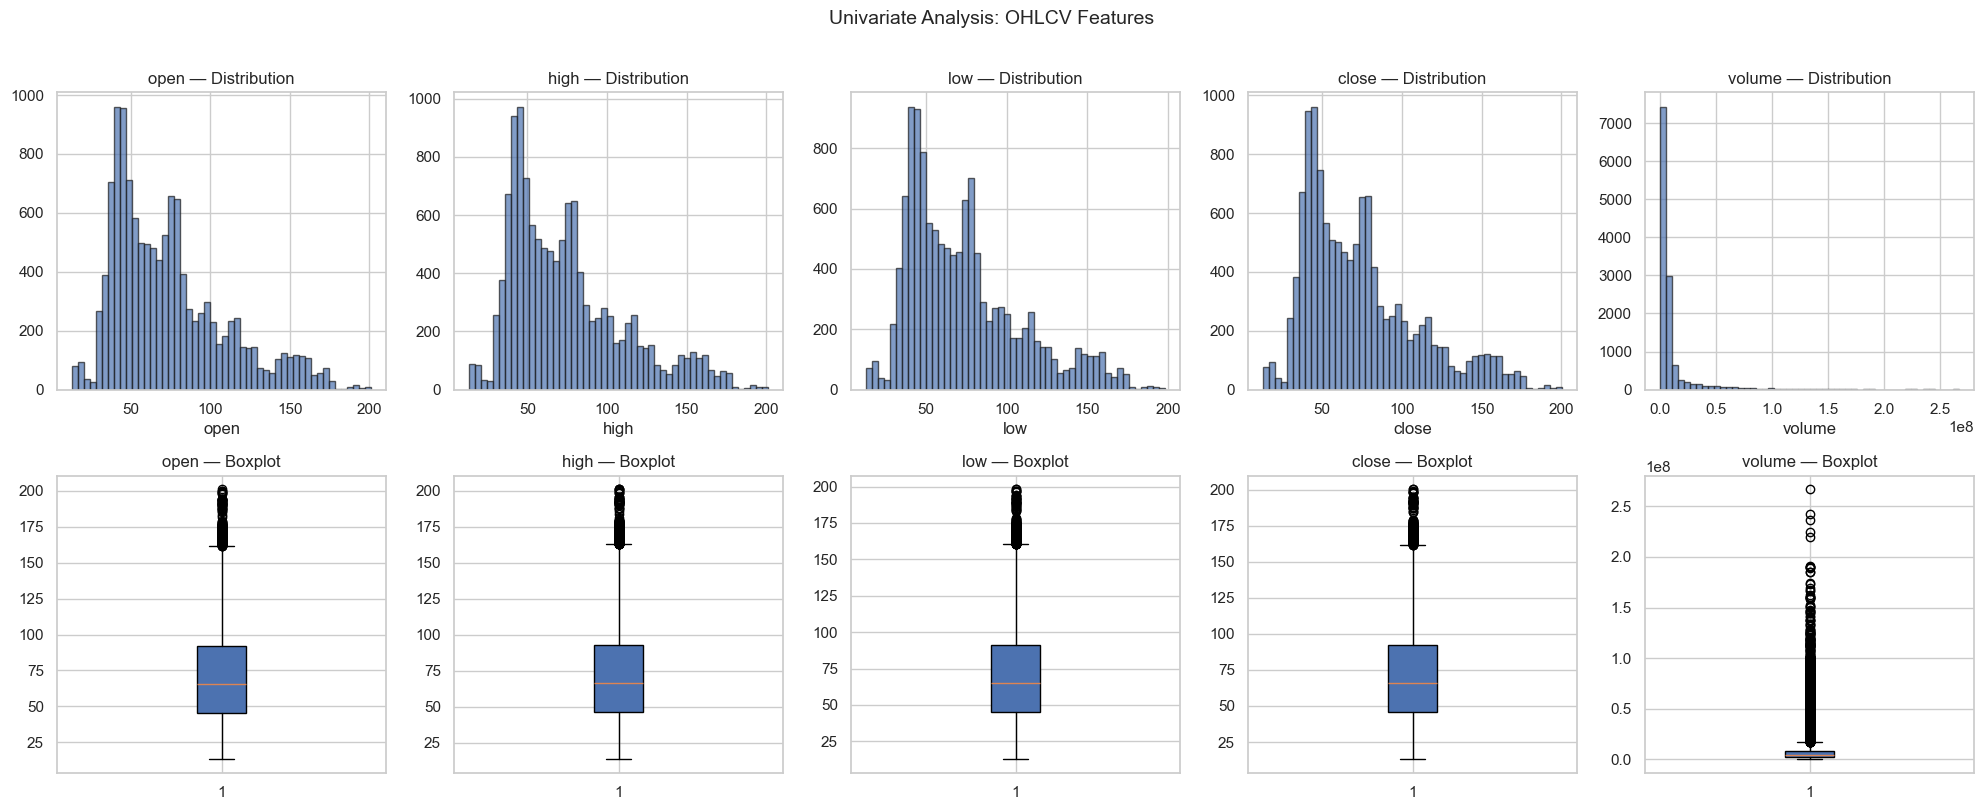

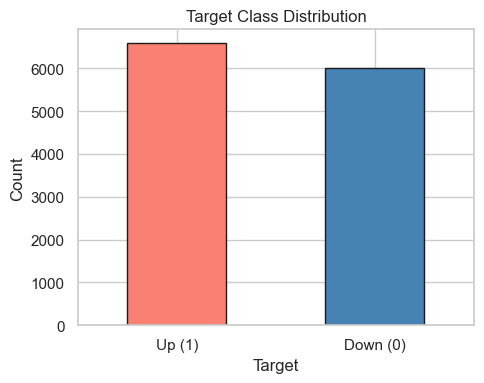

In [9]:
# Step 2.2 — Univariate Analysis (display only — no save)
num_cols = ['open', 'high', 'low', 'close', 'volume']

fig, axes = plt.subplots(2, len(num_cols), figsize=(20, 8))
for i, col in enumerate(num_cols):
    axes[0, i].hist(df[col], bins=50, edgecolor='k', alpha=0.7)
    axes[0, i].set_title(f'{col} — Distribution')
    axes[0, i].set_xlabel(col)
    axes[1, i].boxplot(df[col], vert=True, patch_artist=True)
    axes[1, i].set_title(f'{col} — Boxplot')
plt.suptitle('Univariate Analysis: OHLCV Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Target class balance bar chart
fig, ax = plt.subplots(figsize=(5, 4))
(df['target'].value_counts()
             .rename({0: 'Down (0)', 1: 'Up (1)'})
             .plot(kind='bar', ax=ax, color=['salmon', 'steelblue'], edgecolor='k'))
ax.set_title('Target Class Distribution')
ax.set_ylabel('Count')
ax.set_xlabel('Target')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

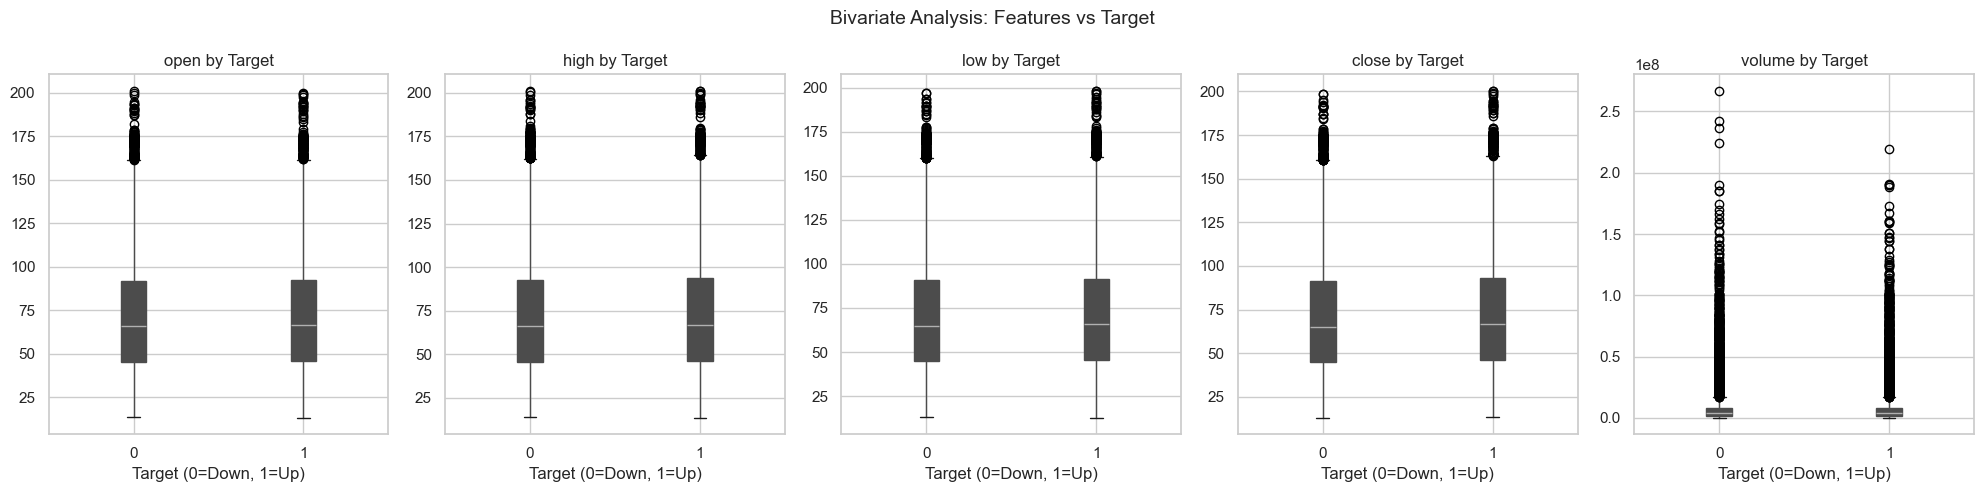

=== Mean feature values by target ===


,open,high,low,close,volume
target,,,,,
0,73.74,74.14,72.78,73.19,10071744.39
1,73.54,74.45,73.17,74.09,9580222.21


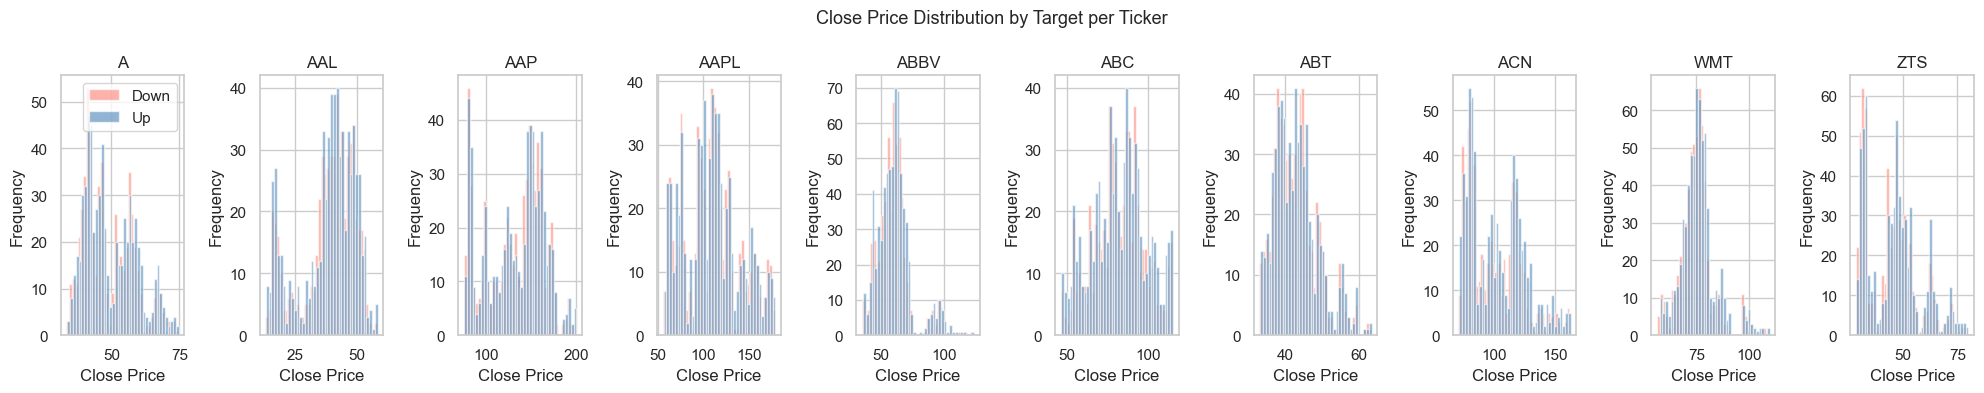

In [10]:
# Step 2.3 — Bivariate Analysis (display only — no save)
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 5))
for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='target', ax=axes[i], patch_artist=True)
    axes[i].set_title(f'{col} by Target')
    axes[i].set_xlabel('Target (0=Down, 1=Up)')
plt.suptitle('Bivariate Analysis: Features vs Target', fontsize=14)
plt.tight_layout()
plt.show()

print("=== Mean feature values by target ===")
display(df.groupby('target')[num_cols].mean().round(2))

# Close price distribution per ticker coloured by target
tickers_sorted = sorted(df['Name'].unique())
fig, axes = plt.subplots(1, len(tickers_sorted), figsize=(20, 4), sharey=False)
for ax, ticker in zip(axes, tickers_sorted):
    sub = df[df['Name'] == ticker]
    for label, color in [(0, 'salmon'), (1, 'steelblue')]:
        sub[sub['target'] == label]['close'].plot(kind='hist', bins=40,
            alpha=0.6, color=color, ax=ax)
    ax.set_title(ticker)
    ax.set_xlabel('Close Price')
axes[0].legend(['Down', 'Up'])
plt.suptitle('Close Price Distribution by Target per Ticker', fontsize=13)
plt.tight_layout()
plt.show()

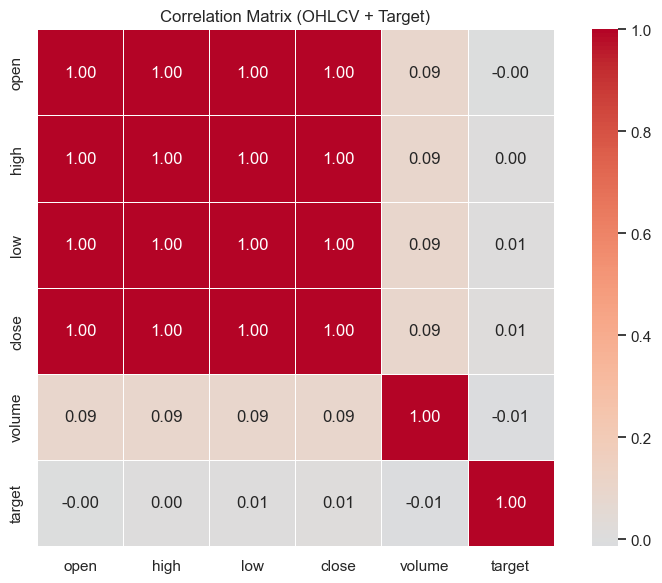

=== Correlation with Target ===
close     0.0127
low       0.0056
high      0.0044
open     -0.0028
volume   -0.0131
Name: target, dtype: float64


In [11]:
# Step 2.4 — Correlation Analysis (display only — no save)
corr_cols   = num_cols + ['target']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (OHLCV + Target)')
plt.tight_layout()
plt.show()

print("=== Correlation with Target ===")
print(corr_matrix['target'].drop('target').sort_values(ascending=False).round(4))

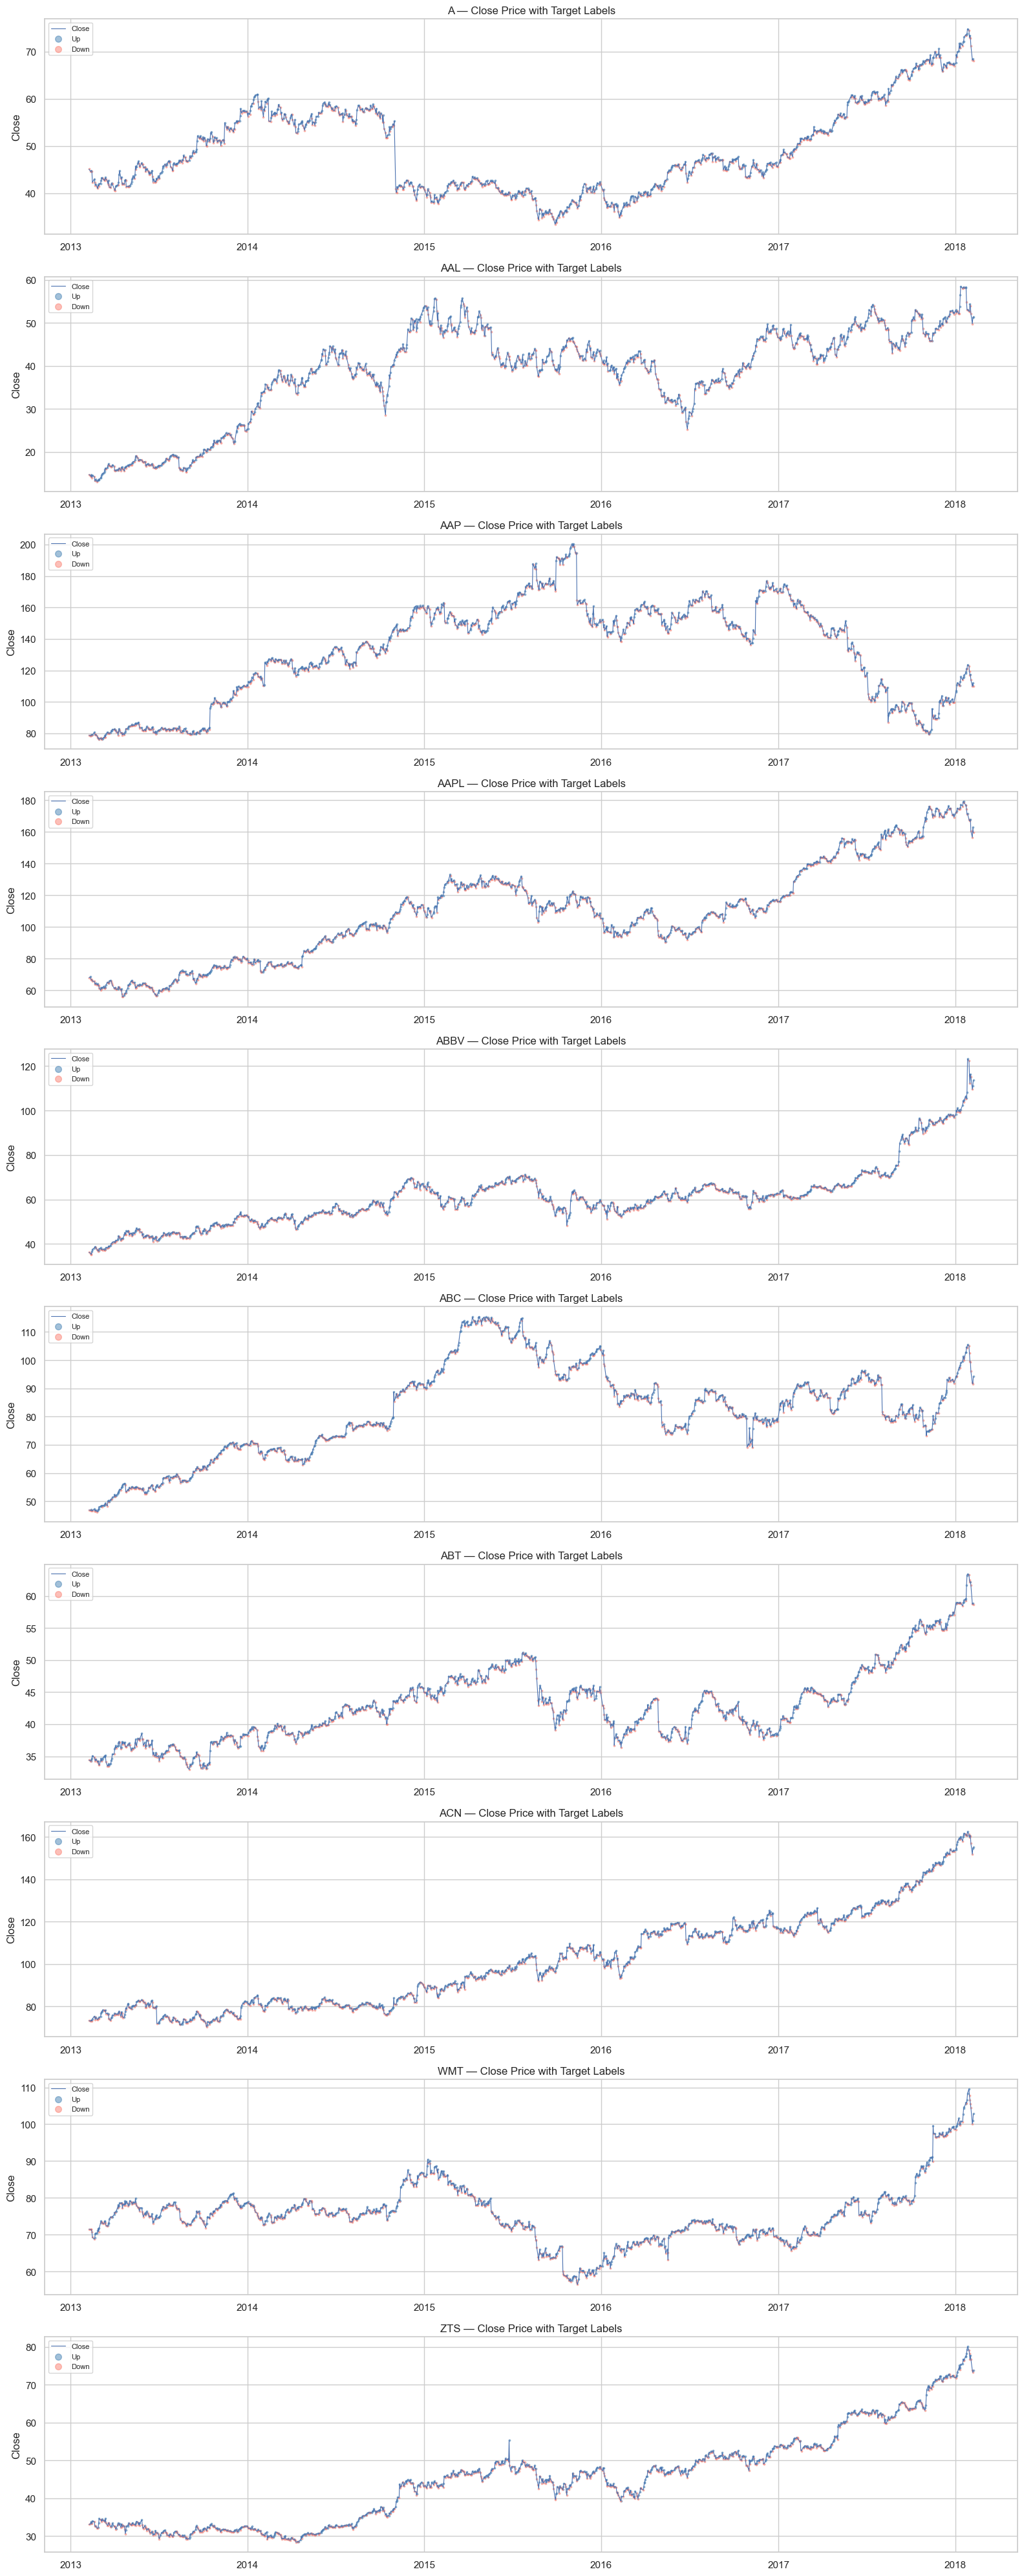

In [12]:
# Step 2.5 — Time Series: Closing Price per Ticker (display only — no save)
tickers_sorted = sorted(df['Name'].unique())
fig, axes = plt.subplots(len(tickers_sorted), 1,
                         figsize=(16, 4 * len(tickers_sorted)), sharex=False)

for ax, ticker in zip(axes, tickers_sorted):
    sub       = df[df['Name'] == ticker].set_index('date')
    up_days   = sub[sub['target'] == 1]
    down_days = sub[sub['target'] == 0]
    ax.plot(sub['close'], label='Close', linewidth=0.8)
    ax.scatter(up_days.index,   up_days['close'],
               color='steelblue', s=3, alpha=0.5, label='Up')
    ax.scatter(down_days.index, down_days['close'],
               color='salmon',    s=3, alpha=0.5, label='Down')
    ax.set_title(f'{ticker} — Close Price with Target Labels')
    ax.set_ylabel('Close')
    ax.legend(loc='upper left', markerscale=4, fontsize=8)

plt.tight_layout()
plt.show()

## Section 3 — Feature Engineering

In [13]:
print("=" * 60)
print("=== SECTION 3: FEATURE ENGINEERING ===")
print("=" * 60)

# Step 3.1 — Sort data for per-ticker indicator computation
df = df.sort_values(['Name', 'date']).reset_index(drop=True)
print(f"Shape      : {df.shape}")
print(f"Date range : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Tickers    : {df['Name'].unique().tolist()}")
df.head()

=== SECTION 3: FEATURE ENGINEERING ===
Shape      : (12590, 8)
Date range : 2013-02-08 → 2018-02-07
Tickers    : ['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABC', 'ABT', 'ACN', 'WMT', 'ZTS']


,date,open,high,low,close,volume,Name,target
0,2013-02-08,45.07,45.35,45.00,45.08,1824755,A,0
1,2013-02-11,45.17,45.18,44.45,44.60,2915405,A,0
2,2013-02-12,44.81,44.95,44.50,44.62,2373731,A,1
3,2013-02-13,44.81,45.24,44.68,44.75,2052338,A,1
4,2013-02-14,44.72,44.78,44.36,44.58,3826245,A,0


In [14]:
# Step 3.2 — Add Technical Indicators via `ta` library (per ticker)
# Processing per ticker avoids cross-ticker contamination of rolling windows.
def add_indicators(grp):
    close = grp['close']
    # SMA
    grp['sma_20'] = ta.trend.sma_indicator(close, window=20)
    grp['sma_50'] = ta.trend.sma_indicator(close, window=50)
    # EMA
    grp['ema_12'] = ta.trend.ema_indicator(close, window=12)
    grp['ema_26'] = ta.trend.ema_indicator(close, window=26)
    # MACD
    macd_obj          = ta.trend.MACD(close, window_slow=26, window_fast=12, window_sign=9)
    grp['macd_line']  = macd_obj.macd()
    grp['macd_signal']= macd_obj.macd_signal()
    grp['macd_hist']  = macd_obj.macd_diff()
    # RSI (14)
    grp['rsi_14'] = ta.momentum.rsi(close, window=14)
    # Bollinger Bands
    bb               = ta.volatility.BollingerBands(close, window=20, window_dev=2)
    grp['bb_upper']  = bb.bollinger_hband()
    grp['bb_middle'] = bb.bollinger_mavg()
    grp['bb_lower']  = bb.bollinger_lband()
    grp['bb_pct_b']  = bb.bollinger_pband()   # %B
    return grp

df = df.groupby('Name', group_keys=False).apply(add_indicators)
# Drop warm-up rows (NaN from slowest indicator = SMA-50)
df = df.dropna().reset_index(drop=True)

new_cols = [c for c in df.columns
            if c not in ['date','open','high','low','close','volume','Name','target']]
print(f"Shape after adding indicators: {df.shape}")
print(f"New indicator columns: {new_cols}")
df.head()

Shape after adding indicators: (12100, 19)
New indicator columns: ['sma_20', 'sma_50', 'ema_12', 'ema_26', 'macd_line', 'macd_signal', 'macd_hist', 'rsi_14', 'bb_upper', 'bb_middle', 'bb_lower', 'bb_pct_b']


,date,open,high,low,close,volume,target,sma_20,sma_50,ema_12,ema_26,macd_line,macd_signal,macd_hist,rsi_14,bb_upper,bb_middle,bb_lower,bb_pct_b
0,2013-04-22,42.03,42.2500,41.34,41.85,2340457,0,42.0275,42.4326,42.310040,42.320150,-0.010110,-0.018301,0.008190,46.565393,44.072141,42.0275,39.982859,0.456594
1,2013-04-23,42.21,42.8425,42.13,42.61,3522419,1,42.1015,42.3832,42.356188,42.341620,0.014567,-0.011727,0.026294,51.815841,44.117786,42.1015,40.085214,0.626098
2,2013-04-24,42.72,43.0350,42.37,42.85,3020692,1,42.1530,42.3482,42.432159,42.379278,0.052881,0.001195,0.051686,53.373904,44.190401,42.1530,40.115599,0.671051
3,2013-04-25,43.05,43.2500,42.66,42.73,2119838,0,42.1850,42.3104,42.477980,42.405258,0.072723,0.015500,0.057223,52.460490,44.237486,42.1850,40.132514,0.632766
4,2013-04-26,42.44,42.5700,40.69,41.30,5283798,0,42.1515,42.2414,42.296753,42.323387,-0.026634,0.007073,-0.033707,43.013684,44.238510,42.1515,40.064490,0.296000


In [15]:
# Step 3.3 — Create Feature Matrix (X) and Response Vector (y)
feature_cols = [
    'open', 'high', 'low', 'close', 'volume',
    'sma_20', 'sma_50', 'ema_12', 'ema_26',
    'macd_line', 'macd_signal', 'macd_hist',
    'rsi_14',
    'bb_upper', 'bb_middle', 'bb_lower', 'bb_pct_b'
]

X = df[feature_cols].copy()
y = df['target'].copy()

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"\ny value counts:\n{y.value_counts()}")

X shape : (12100, 17)
y shape : (12100,)

y value counts:
target
1    6318
0    5782
Name: count, dtype: int64


In [16]:
# Step 3.4 — Chronological Train-Test Split (~80/20 by year boundary)
# Stock data is temporal — split strictly by date, never randomly.
# Strategy: snap cut-off to the full-year boundary closest to an 80/20 split.
years = sorted(df['date'].dt.year.unique())
total = len(df)

best_year, best_diff = None, float('inf')
for yr in years[:-1]:
    n_train = (df['date'].dt.year <= yr).sum()
    diff    = abs(n_train / total - 0.80)
    if diff < best_diff:
        best_diff, best_year = diff, yr

cutoff_date = pd.Timestamp(f'{best_year}-12-31')
train_mask  = df['date'] <= cutoff_date
X_train, X_test = X[train_mask].copy(), X[~train_mask].copy()
y_train, y_test = y[train_mask].copy(), y[~train_mask].copy()

print(f"Cut-off date  : {cutoff_date.date()}")
print(f"Train period  : {df.loc[train_mask,  'date'].min().date()} → "
      f"{df.loc[train_mask,  'date'].max().date()}")
print(f"Test  period  : {df.loc[~train_mask, 'date'].min().date()} → "
      f"{df.loc[~train_mask, 'date'].max().date()}")
print(f"\nX_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}  |  y_test : {y_test.shape}")
print(f"Actual split  : {len(X_train)/total:.1%} train / {len(X_test)/total:.1%} test")

Cut-off date  : 2016-12-31
Train period  : 2013-04-22 → 2016-12-30
Test  period  : 2017-01-03 → 2018-02-07

X_train : (9330, 17)  |  X_test : (2770, 17)
y_train : (9330,)  |  y_test : (2770,)
Actual split  : 77.1% train / 22.9% test


In [17]:
# Step 3.5 — MinMax Scaling
# Fit scaler ONLY on X_train; transform both to prevent data leakage.
# The scaler object is retained in-memory for artifact packaging in Section 6.
scaler         = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),
                               columns=feature_cols, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),
                               columns=feature_cols, index=X_test.index)

print("X_train_scaled — min/max check (should be 0.0 / 1.0 for all cols):")
print(X_train_scaled.agg(['min', 'max']).T.head())
print("\nX_test_scaled — values may fall outside [0,1] due to unseen price ranges:")
print(X_test_scaled.agg(['min', 'max']).T.head())

# Overwrite X_train / X_test with scaled versions for model training
X_train = X_train_scaled
X_test  = X_test_scaled

X_train_scaled — min/max check (should be 0.0 / 1.0 for all cols):
        min  max
open    0.0  1.0
high    0.0  1.0
low     0.0  1.0
close   0.0  1.0
volume  0.0  1.0

X_test_scaled — values may fall outside [0,1] due to unseen price ranges:
             min       max
open    0.125348  0.882362
high    0.126811  0.886167
low     0.126094  0.891131
close   0.128134  0.885863
volume  0.000949  0.419397


In [18]:
# Step 3.6 — Label Encoding Check
# target is already binary integer (0 = Down, 1 = Up).
# sklearn classifiers accept integer labels directly — LabelEncoder is a no-op here.
print("y_train dtype :", y_train.dtype)
print("y_test  dtype :", y_test.dtype)
print(f"\ny_train distribution:\n{y_train.value_counts()}")
print(f"\ny_test  distribution:\n{y_test.value_counts()}")

y_train dtype : int64
y_test  dtype : int64

y_train distribution:
target
1    4818
0    4512
Name: count, dtype: int64

y_test  distribution:
target
1    1500
0    1270
Name: count, dtype: int64


## Section 4 — Model Training & Prediction

In [19]:
print("=" * 60)
print("=== SECTION 4: MODEL TRAINING & PREDICTION ===")
print("=" * 60)

# Helper: print key classification metrics + full classification report
def print_metrics(label, y_true, y_pred, y_prob=None):
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  F1        : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    if y_prob is not None:
        print(f"  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Down (0)', 'Up (1)'], zero_division=0)}")

print("Helper print_metrics() defined.")

=== SECTION 4: MODEL TRAINING & PREDICTION ===
Helper print_metrics() defined.


In [20]:
print("=" * 60)
print("=== STEP 4.1: LOGISTIC REGRESSION — BASELINE ===")
print("=" * 60)
try:
    lr_baseline = LogisticRegression(random_state=42, max_iter=200, n_jobs=-1)
    lr_baseline.fit(X_train, y_train)
    y_pred_lr_base = lr_baseline.predict(X_test)
    y_prob_lr_base = lr_baseline.predict_proba(X_test)[:, 1]
    print_metrics("LR Baseline", y_test, y_pred_lr_base, y_prob_lr_base)
except Exception as e:
    print(f"[ERROR] LR Baseline: {e}")

=== STEP 4.1: LOGISTIC REGRESSION — BASELINE ===
  Accuracy  : 0.6690
  Precision : 0.6628
  Recall    : 0.7913
  F1        : 0.7214
  ROC-AUC   : 0.7424

              precision    recall  f1-score   support

    Down (0)       0.68      0.52      0.59      1270
      Up (1)       0.66      0.79      0.72      1500

    accuracy                           0.67      2770
   macro avg       0.67      0.66      0.66      2770
weighted avg       0.67      0.67      0.66      2770



In [21]:
print("=" * 60)
print("=== STEP 4.1: LOGISTIC REGRESSION — HYPERPARAMETER TUNING ===")
print("=" * 60)

# GridSearchCV — 5-fold CV, refit on roc_auc
lr_param_grid = {
    'C'       : [0.01, 0.1, 1, 10, 100],
    'penalty' : ['l1', 'l2'],
    'solver'  : ['liblinear', 'saga'],
    'max_iter': [200, 500]
}
lr_scoring = {'roc_auc': 'roc_auc', 'f1': 'f1', 'accuracy': 'accuracy',
              'precision': 'precision', 'recall': 'recall'}
try:
    lr_grid = GridSearchCV(
        estimator  = LogisticRegression(random_state=42, n_jobs=-1),
        param_grid = lr_param_grid,
        scoring    = lr_scoring,
        refit      = 'roc_auc',
        cv         = 5,
        n_jobs     = -1,
        verbose    = 1
    )
    lr_grid.fit(X_train, y_train)
    print("\nBest hyperparameters:")
    for k, v in lr_grid.best_params_.items():
        print(f"  {k}: {v}")
    print(f"\nBest CV ROC-AUC: {lr_grid.best_score_:.4f}")
except Exception as e:
    print(f"[ERROR] LR Tuning: {e}")

=== STEP 4.1: LOGISTIC REGRESSION — HYPERPARAMETER TUNING ===
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best hyperparameters:
  C: 100
  max_iter: 500
  penalty: l1
  solver: liblinear

Best CV ROC-AUC: 0.9363


In [22]:
print("=" * 60)
print("=== STEP 4.1: LOGISTIC REGRESSION — FINAL PREDICTIONS ===")
print("=" * 60)
try:
    lr_best   = lr_grid.best_estimator_
    y_pred_lr = lr_best.predict(X_test)
    y_prob_lr = lr_best.predict_proba(X_test)[:, 1]
    print_metrics("LR Tuned", y_test, y_pred_lr, y_prob_lr)
except Exception as e:
    print(f"[ERROR] LR Final Predictions: {e}")

=== STEP 4.1: LOGISTIC REGRESSION — FINAL PREDICTIONS ===
  Accuracy  : 0.8610
  Precision : 0.8535
  Recall    : 0.8973
  F1        : 0.8749
  ROC-AUC   : 0.9354

              precision    recall  f1-score   support

    Down (0)       0.87      0.82      0.84      1270
      Up (1)       0.85      0.90      0.87      1500

    accuracy                           0.86      2770
   macro avg       0.86      0.86      0.86      2770
weighted avg       0.86      0.86      0.86      2770



In [23]:
print("=" * 60)
print("=== STEP 4.2: SUPPORT VECTOR MACHINE — BASELINE ===")
print("=" * 60)
# probability=True is required to compute ROC-AUC
try:
    svc_baseline = SVC(random_state=42, probability=True)
    svc_baseline.fit(X_train, y_train)
    y_pred_svc_base = svc_baseline.predict(X_test)
    y_prob_svc_base = svc_baseline.predict_proba(X_test)[:, 1]
    print_metrics("SVM Baseline", y_test, y_pred_svc_base, y_prob_svc_base)
except Exception as e:
    print(f"[ERROR] SVM Baseline: {e}")

=== STEP 4.2: SUPPORT VECTOR MACHINE — BASELINE ===
  Accuracy  : 0.7079
  Precision : 0.6987
  Recall    : 0.8100
  F1        : 0.7502
  ROC-AUC   : 0.7766

              precision    recall  f1-score   support

    Down (0)       0.72      0.59      0.65      1270
      Up (1)       0.70      0.81      0.75      1500

    accuracy                           0.71      2770
   macro avg       0.71      0.70      0.70      2770
weighted avg       0.71      0.71      0.70      2770



In [24]:
print("=" * 60)
print("=== STEP 4.2: SUPPORT VECTOR MACHINE — HYPERPARAMETER TUNING ===")
print("=" * 60)

# GridSearchCV — 5-fold CV, refit on roc_auc
svc_param_grid = {
    'C'     : [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma' : ['scale', 'auto']
}
svc_scoring = {'roc_auc': 'roc_auc', 'f1': 'f1', 'accuracy': 'accuracy',
               'precision': 'precision', 'recall': 'recall'}
try:
    svc_grid = GridSearchCV(
        estimator  = SVC(random_state=42, probability=True),
        param_grid = svc_param_grid,
        scoring    = svc_scoring,
        refit      = 'roc_auc',
        cv         = 5,
        n_jobs     = -1,
        verbose    = 1
    )
    svc_grid.fit(X_train, y_train)
    print("\nBest hyperparameters:")
    for k, v in svc_grid.best_params_.items():
        print(f"  {k}: {v}")
    print(f"\nBest CV ROC-AUC: {svc_grid.best_score_:.4f}")
except Exception as e:
    print(f"[ERROR] SVM Tuning: {e}")

=== STEP 4.2: SUPPORT VECTOR MACHINE — HYPERPARAMETER TUNING ===
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best hyperparameters:
  C: 100
  gamma: scale
  kernel: poly

Best CV ROC-AUC: 0.9257


In [25]:
print("=" * 60)
print("=== STEP 4.2: SUPPORT VECTOR MACHINE — FINAL PREDICTIONS ===")
print("=" * 60)
try:
    svc_best   = svc_grid.best_estimator_
    y_pred_svc = svc_best.predict(X_test)
    y_prob_svc = svc_best.predict_proba(X_test)[:, 1]
    print_metrics("SVM Tuned", y_test, y_pred_svc, y_prob_svc)
except Exception as e:
    print(f"[ERROR] SVM Final Predictions: {e}")

=== STEP 4.2: SUPPORT VECTOR MACHINE — FINAL PREDICTIONS ===
  Accuracy  : 0.8549
  Precision : 0.8607
  Recall    : 0.8733
  F1        : 0.8670
  ROC-AUC   : 0.9316

              precision    recall  f1-score   support

    Down (0)       0.85      0.83      0.84      1270
      Up (1)       0.86      0.87      0.87      1500

    accuracy                           0.85      2770
   macro avg       0.85      0.85      0.85      2770
weighted avg       0.85      0.85      0.85      2770



In [26]:
print("=" * 60)
print("=== STEP 4.3: DECISION TREE — BASELINE ===")
print("=" * 60)
try:
    dt_baseline = DecisionTreeClassifier(random_state=42)
    dt_baseline.fit(X_train, y_train)
    y_pred_dt_base = dt_baseline.predict(X_test)
    y_prob_dt_base = dt_baseline.predict_proba(X_test)[:, 1]
    print_metrics("DT Baseline", y_test, y_pred_dt_base, y_prob_dt_base)
except Exception as e:
    print(f"[ERROR] DT Baseline: {e}")

=== STEP 4.3: DECISION TREE — BASELINE ===
  Accuracy  : 0.6462
  Precision : 0.6667
  Recall    : 0.6933
  F1        : 0.6797
  ROC-AUC   : 0.6419

              precision    recall  f1-score   support

    Down (0)       0.62      0.59      0.60      1270
      Up (1)       0.67      0.69      0.68      1500

    accuracy                           0.65      2770
   macro avg       0.64      0.64      0.64      2770
weighted avg       0.65      0.65      0.65      2770



In [27]:
print("=" * 60)
print("=== STEP 4.3: DECISION TREE — HYPERPARAMETER TUNING ===")
print("=" * 60)

# GridSearchCV — 5-fold CV, scored on roc_auc
dt_param_grid = {
    'max_depth'        : [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 4, 8],
    'criterion'        : ['gini', 'entropy']
}
try:
    dt_grid = GridSearchCV(
        estimator  = DecisionTreeClassifier(random_state=42),
        param_grid = dt_param_grid,
        scoring    = 'roc_auc',
        refit      = True,
        cv         = 5,
        n_jobs     = -1,
        verbose    = 1
    )
    dt_grid.fit(X_train, y_train)
    print("\nBest hyperparameters:")
    for k, v in dt_grid.best_params_.items():
        print(f"  {k}: {v}")
    print(f"\nBest CV ROC-AUC: {dt_grid.best_score_:.4f}")
except Exception as e:
    print(f"[ERROR] DT Tuning: {e}")

=== STEP 4.3: DECISION TREE — HYPERPARAMETER TUNING ===
Fitting 5 folds for each of 160 candidates, totalling 800 fits

Best hyperparameters:
  criterion: entropy
  max_depth: 7
  min_samples_leaf: 8
  min_samples_split: 20

Best CV ROC-AUC: 0.7485


In [28]:
print("=" * 60)
print("=== STEP 4.3: DECISION TREE — FINAL PREDICTIONS ===")
print("=" * 60)
try:
    dt_best   = dt_grid.best_estimator_
    y_pred_dt = dt_best.predict(X_test)
    y_prob_dt = dt_best.predict_proba(X_test)[:, 1]
    print_metrics("DT Tuned", y_test, y_pred_dt, y_prob_dt)
except Exception as e:
    print(f"[ERROR] DT Final Predictions: {e}")

=== STEP 4.3: DECISION TREE — FINAL PREDICTIONS ===
  Accuracy  : 0.6848
  Precision : 0.7161
  Recall    : 0.6927
  F1        : 0.7042
  ROC-AUC   : 0.7498

              precision    recall  f1-score   support

    Down (0)       0.65      0.68      0.66      1270
      Up (1)       0.72      0.69      0.70      1500

    accuracy                           0.68      2770
   macro avg       0.68      0.68      0.68      2770
weighted avg       0.69      0.68      0.69      2770



In [29]:
print("=" * 60)
print("=== STEP 4.4: RANDOM FOREST — BASELINE ===")
print("=" * 60)
try:
    rf_baseline = RandomForestClassifier(random_state=42, n_jobs=-1)
    rf_baseline.fit(X_train, y_train)
    y_pred_rf_base = rf_baseline.predict(X_test)
    y_prob_rf_base = rf_baseline.predict_proba(X_test)[:, 1]
    print_metrics("RF Baseline", y_test, y_pred_rf_base, y_prob_rf_base)
except Exception as e:
    print(f"[ERROR] RF Baseline: {e}")

=== STEP 4.4: RANDOM FOREST — BASELINE ===
  Accuracy  : 0.7144
  Precision : 0.7187
  Recall    : 0.7767
  F1        : 0.7466
  ROC-AUC   : 0.7880

              precision    recall  f1-score   support

    Down (0)       0.71      0.64      0.67      1270
      Up (1)       0.72      0.78      0.75      1500

    accuracy                           0.71      2770
   macro avg       0.71      0.71      0.71      2770
weighted avg       0.71      0.71      0.71      2770



In [30]:
print("=" * 60)
print("=== STEP 4.4: RANDOM FOREST — HYPERPARAMETER TUNING ===")
print("=" * 60)

# RandomizedSearchCV — faster than GridSearch for large param spaces
rf_param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}
try:
    rf_search = RandomizedSearchCV(
        estimator           = RandomForestClassifier(random_state=42, n_jobs=-1),
        param_distributions = rf_param_dist,
        n_iter              = 30,
        scoring             = 'roc_auc',
        refit               = True,
        cv                  = 5,
        n_jobs              = -1,
        random_state        = 42,
        verbose             = 1
    )
    rf_search.fit(X_train, y_train)
    print("\nBest hyperparameters:")
    for k, v in rf_search.best_params_.items():
        print(f"  {k}: {v}")
    print(f"\nBest CV ROC-AUC: {rf_search.best_score_:.4f}")
except Exception as e:
    print(f"[ERROR] RF Tuning: {e}")

=== STEP 4.4: RANDOM FOREST — HYPERPARAMETER TUNING ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best hyperparameters:
  n_estimators: 300
  min_samples_split: 10
  min_samples_leaf: 4
  max_features: log2
  max_depth: None

Best CV ROC-AUC: 0.7912


In [31]:
print("=" * 60)
print("=== STEP 4.4: RANDOM FOREST — FINAL PREDICTIONS ===")
print("=" * 60)
try:
    rf_best   = rf_search.best_estimator_
    y_pred_rf = rf_best.predict(X_test)
    y_prob_rf = rf_best.predict_proba(X_test)[:, 1]
    print_metrics("RF Tuned", y_test, y_pred_rf, y_prob_rf)
except Exception as e:
    print(f"[ERROR] RF Final Predictions: {e}")

=== STEP 4.4: RANDOM FOREST — FINAL PREDICTIONS ===
  Accuracy  : 0.7184
  Precision : 0.7190
  Recall    : 0.7880
  F1        : 0.7519
  ROC-AUC   : 0.7950

              precision    recall  f1-score   support

    Down (0)       0.72      0.64      0.67      1270
      Up (1)       0.72      0.79      0.75      1500

    accuracy                           0.72      2770
   macro avg       0.72      0.71      0.71      2770
weighted avg       0.72      0.72      0.72      2770



In [32]:
print("=" * 60)
print("=== STEP 4.5: ADABOOST — BASELINE ===")
print("=" * 60)
try:
    ada_baseline = AdaBoostClassifier(random_state=42)
    ada_baseline.fit(X_train, y_train)
    y_pred_ada_base = ada_baseline.predict(X_test)
    y_prob_ada_base = ada_baseline.predict_proba(X_test)[:, 1]
    print_metrics("AdaBoost Baseline", y_test, y_pred_ada_base, y_prob_ada_base)
except Exception as e:
    print(f"[ERROR] AdaBoost Baseline: {e}")

=== STEP 4.5: ADABOOST — BASELINE ===
  Accuracy  : 0.6646
  Precision : 0.6571
  Recall    : 0.7960
  F1        : 0.7199
  ROC-AUC   : 0.7545

              precision    recall  f1-score   support

    Down (0)       0.68      0.51      0.58      1270
      Up (1)       0.66      0.80      0.72      1500

    accuracy                           0.66      2770
   macro avg       0.67      0.65      0.65      2770
weighted avg       0.67      0.66      0.66      2770



In [33]:
print("=" * 60)
print("=== STEP 4.5: ADABOOST — HYPERPARAMETER TUNING ===")
print("=" * 60)

# Note: 'algorithm' parameter removed — scikit-learn >= 1.6 only supports SAMME.
ada_param_grid = {
    'n_estimators' : [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}
ada_scoring = {'roc_auc': 'roc_auc', 'f1': 'f1', 'accuracy': 'accuracy',
               'precision': 'precision', 'recall': 'recall'}
try:
    ada_grid = GridSearchCV(
        estimator  = AdaBoostClassifier(random_state=42),
        param_grid = ada_param_grid,
        scoring    = ada_scoring,
        refit      = 'roc_auc',
        cv         = 5,
        n_jobs     = -1,
        verbose    = 1
    )
    ada_grid.fit(X_train, y_train)
    print("\nBest hyperparameters:")
    for k, v in ada_grid.best_params_.items():
        print(f"  {k}: {v}")
    print(f"\nBest CV ROC-AUC: {ada_grid.best_score_:.4f}")
except Exception as e:
    print(f"[ERROR] AdaBoost Tuning: {e}")

=== STEP 4.5: ADABOOST — HYPERPARAMETER TUNING ===
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best hyperparameters:
  learning_rate: 1.0
  n_estimators: 300

Best CV ROC-AUC: 0.7806


In [34]:
print("=" * 60)
print("=== STEP 4.5: ADABOOST — FINAL PREDICTIONS ===")
print("=" * 60)
try:
    ada_best   = ada_grid.best_estimator_
    y_pred_ada = ada_best.predict(X_test)
    y_prob_ada = ada_best.predict_proba(X_test)[:, 1]
    print_metrics("AdaBoost Tuned", y_test, y_pred_ada, y_prob_ada)
except Exception as e:
    print(f"[ERROR] AdaBoost Final Predictions: {e}")

=== STEP 4.5: ADABOOST — FINAL PREDICTIONS ===
  Accuracy  : 0.7025
  Precision : 0.7036
  Recall    : 0.7787
  F1        : 0.7392
  ROC-AUC   : 0.7736

              precision    recall  f1-score   support

    Down (0)       0.70      0.61      0.65      1270
      Up (1)       0.70      0.78      0.74      1500

    accuracy                           0.70      2770
   macro avg       0.70      0.70      0.70      2770
weighted avg       0.70      0.70      0.70      2770



In [35]:
print("=" * 60)
print("=== STEP 4.6: GRADIENT BOOSTING (GBM) — BASELINE ===")
print("=" * 60)
try:
    gbm_baseline = GradientBoostingClassifier(random_state=42)
    gbm_baseline.fit(X_train, y_train)
    y_pred_gbm_base = gbm_baseline.predict(X_test)
    y_prob_gbm_base = gbm_baseline.predict_proba(X_test)[:, 1]
    print_metrics("GBM Baseline", y_test, y_pred_gbm_base, y_prob_gbm_base)
except Exception as e:
    print(f"[ERROR] GBM Baseline: {e}")

=== STEP 4.6: GRADIENT BOOSTING (GBM) — BASELINE ===
  Accuracy  : 0.7130
  Precision : 0.7140
  Recall    : 0.7840
  F1        : 0.7474
  ROC-AUC   : 0.7928

              precision    recall  f1-score   support

    Down (0)       0.71      0.63      0.67      1270
      Up (1)       0.71      0.78      0.75      1500

    accuracy                           0.71      2770
   macro avg       0.71      0.71      0.71      2770
weighted avg       0.71      0.71      0.71      2770



In [36]:
print("=" * 60)
print("=== STEP 4.6: GRADIENT BOOSTING (GBM) — HYPERPARAMETER TUNING ===")
print("=" * 60)

gbm_param_dist = {
    'n_estimators'     : [100, 200, 300],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'max_depth'        : [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'subsample'        : [0.7, 0.8, 1.0]
}
try:
    gbm_search = RandomizedSearchCV(
        estimator           = GradientBoostingClassifier(random_state=42),
        param_distributions = gbm_param_dist,
        n_iter              = 30,
        scoring             = 'roc_auc',
        refit               = True,
        cv                  = 5,
        n_jobs              = -1,
        random_state        = 42,
        verbose             = 1
    )
    gbm_search.fit(X_train, y_train)
    print("\nBest hyperparameters:")
    for k, v in gbm_search.best_params_.items():
        print(f"  {k}: {v}")
    print(f"\nBest CV ROC-AUC: {gbm_search.best_score_:.4f}")
except Exception as e:
    print(f"[ERROR] GBM Tuning: {e}")

=== STEP 4.6: GRADIENT BOOSTING (GBM) — HYPERPARAMETER TUNING ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best hyperparameters:
  subsample: 0.8
  n_estimators: 300
  min_samples_split: 5
  max_depth: 7
  learning_rate: 0.2

Best CV ROC-AUC: 0.8144


In [37]:
print("=" * 60)
print("=== STEP 4.6: GRADIENT BOOSTING (GBM) — FINAL PREDICTIONS ===")
print("=" * 60)
try:
    gbm_best   = gbm_search.best_estimator_
    y_pred_gbm = gbm_best.predict(X_test)
    y_prob_gbm = gbm_best.predict_proba(X_test)[:, 1]
    print_metrics("GBM Tuned", y_test, y_pred_gbm, y_prob_gbm)
except Exception as e:
    print(f"[ERROR] GBM Final Predictions: {e}")

=== STEP 4.6: GRADIENT BOOSTING (GBM) — FINAL PREDICTIONS ===
  Accuracy  : 0.7455
  Precision : 0.7387
  Recall    : 0.8200
  F1        : 0.7773
  ROC-AUC   : 0.8215

              precision    recall  f1-score   support

    Down (0)       0.76      0.66      0.70      1270
      Up (1)       0.74      0.82      0.78      1500

    accuracy                           0.75      2770
   macro avg       0.75      0.74      0.74      2770
weighted avg       0.75      0.75      0.74      2770



In [38]:
print("=" * 60)
print("=== STEP 4.7: XGBOOST — BASELINE ===")
print("=" * 60)
try:
    xgb_baseline = XGBClassifier(
        random_state=42, n_jobs=-1, eval_metric='logloss', verbosity=0)
    xgb_baseline.fit(X_train, y_train)
    y_pred_xgb_base = xgb_baseline.predict(X_test)
    y_prob_xgb_base = xgb_baseline.predict_proba(X_test)[:, 1]
    print_metrics("XGBoost Baseline", y_test, y_pred_xgb_base, y_prob_xgb_base)
except Exception as e:
    print(f"[ERROR] XGBoost Baseline: {e}")

=== STEP 4.7: XGBOOST — BASELINE ===
  Accuracy  : 0.7296
  Precision : 0.7226
  Recall    : 0.8127
  F1        : 0.7650
  ROC-AUC   : 0.8066

              precision    recall  f1-score   support

    Down (0)       0.74      0.63      0.68      1270
      Up (1)       0.72      0.81      0.76      1500

    accuracy                           0.73      2770
   macro avg       0.73      0.72      0.72      2770
weighted avg       0.73      0.73      0.73      2770



In [39]:
print("=" * 60)
print("=== STEP 4.7: XGBOOST — HYPERPARAMETER TUNING ===")
print("=" * 60)

# L1 (reg_alpha) and L2 (reg_lambda) regularisation included
xgb_param_dist = {
    'n_estimators'    : [100, 200, 300, 500],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'max_depth'       : [3, 5, 7, 9],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha'       : [0, 0.1, 0.5, 1.0],
    'reg_lambda'      : [0.5, 1.0, 2.0, 5.0]
}
try:
    xgb_search = RandomizedSearchCV(
        estimator           = XGBClassifier(
                                  random_state=42, n_jobs=-1,
                                  eval_metric='logloss', verbosity=0),
        param_distributions = xgb_param_dist,
        n_iter              = 20,
        scoring             = 'roc_auc',
        refit               = True,
        cv                  = 5,
        n_jobs              = -1,
        random_state        = 42,
        verbose             = 1
    )
    xgb_search.fit(X_train, y_train)
    print("\nBest hyperparameters:")
    for k, v in xgb_search.best_params_.items():
        print(f"  {k}: {v}")
    print(f"\nBest CV ROC-AUC: {xgb_search.best_score_:.4f}")
except Exception as e:
    print(f"[ERROR] XGBoost Tuning: {e}")

=== STEP 4.7: XGBOOST — HYPERPARAMETER TUNING ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best hyperparameters:
  subsample: 0.8
  reg_lambda: 5.0
  reg_alpha: 0.1
  n_estimators: 500
  max_depth: 5
  learning_rate: 0.05
  colsample_bytree: 1.0

Best CV ROC-AUC: 0.8123


In [40]:
print("=" * 60)
print("=== STEP 4.7: XGBOOST — FINAL PREDICTIONS ===")
print("=" * 60)
try:
    xgb_best   = xgb_search.best_estimator_
    y_pred_xgb = xgb_best.predict(X_test)
    y_prob_xgb = xgb_best.predict_proba(X_test)[:, 1]
    print_metrics("XGBoost Tuned", y_test, y_pred_xgb, y_prob_xgb)
except Exception as e:
    print(f"[ERROR] XGBoost Final Predictions: {e}")

=== STEP 4.7: XGBOOST — FINAL PREDICTIONS ===
  Accuracy  : 0.7321
  Precision : 0.7267
  Recall    : 0.8100
  F1        : 0.7661
  ROC-AUC   : 0.8093

              precision    recall  f1-score   support

    Down (0)       0.74      0.64      0.69      1270
      Up (1)       0.73      0.81      0.77      1500

    accuracy                           0.73      2770
   macro avg       0.73      0.73      0.73      2770
weighted avg       0.73      0.73      0.73      2770



## Section 5 — Model Evaluation

In [41]:
print("=" * 60)
print("=== SECTION 5: MODEL EVALUATION ===")
print("=" * 60)

# Step 5.1 — evaluate_model helper and model registry
def evaluate_model(model, X_test, y_test, model_label):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    metrics = {
        "Model"    : model_label,
        "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall"   : round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1"       : round(f1_score(y_test, y_pred, zero_division=0), 4),
        "ROC-AUC"  : round(roc_auc_score(y_test, y_prob), 4) if y_prob is not None else None,
    }
    return metrics, y_pred, y_prob

# Map internal variable names → display labels
model_display_names = {
    "lr_baseline"  : "LR Baseline",
    "svc_baseline" : "SVM Baseline",
    "dt_baseline"  : "DT Baseline",
    "rf_baseline"  : "RF Baseline",
    "ada_baseline" : "AdaBoost Baseline",
    "gbm_baseline" : "GBM Baseline",
    "xgb_baseline" : "XGBoost Baseline",
    "lr_best"      : "LR Tuned",
    "svc_best"     : "SVM Tuned",
    "dt_best"      : "DT Tuned",
    "rf_best"      : "RF Tuned",
    "ada_best"     : "AdaBoost Tuned",
    "gbm_best"     : "GBM Tuned",
    "xgb_best"     : "XGBoost Tuned",
}

# Build models dict from in-memory variables (no disk load needed)
models = {}
model_vars = {
    "lr_baseline": "lr_baseline", "svc_baseline": "svc_baseline",
    "dt_baseline": "dt_baseline", "rf_baseline":  "rf_baseline",
    "ada_baseline":"ada_baseline","gbm_baseline": "gbm_baseline",
    "xgb_baseline":"xgb_baseline",
    "lr_best":  "lr_best",  "svc_best": "svc_best",
    "dt_best":  "dt_best",  "rf_best":  "rf_best",
    "ada_best": "ada_best", "gbm_best": "gbm_best",
    "xgb_best": "xgb_best",
}
import sys
_mod = sys.modules[__name__] if hasattr(sys.modules[__name__], '__name__') else None
_globs = globals()
for key in model_vars:
    if key in _globs:
        models[key] = _globs[key]
    else:
        print(f"  [MISSING] {key} — re-run Section 4")

print(f"Models available: {len(models)} / {len(model_vars)}")

=== SECTION 5: MODEL EVALUATION ===
Models available: 14 / 14


In [42]:
# Step 5.2 — Compute Metrics for All 14 Models (baseline + tuned)
all_metrics = []
all_preds   = {}
all_probs   = {}

for model_key, display_label in model_display_names.items():
    if model_key not in models:
        print(f"  [SKIP] {model_key} not available.")
        continue
    try:
        m, y_pred, y_prob = evaluate_model(
            models[model_key], X_test, y_test, display_label)
        all_metrics.append(m)
        all_preds[model_key] = y_pred
        all_probs[model_key] = y_prob
        print(f"  {display_label:<22} | Acc={m['Accuracy']:.4f}  "
              f"Prec={m['Precision']:.4f}  Rec={m['Recall']:.4f}  "
              f"F1={m['F1']:.4f}  AUC={m['ROC-AUC']}")
    except Exception as e:
        print(f"  [ERROR] {model_key}: {e}")

metrics_df = pd.DataFrame(all_metrics)
print(f"\nMetrics computed for {len(all_metrics)} models.")

  LR Baseline            | Acc=0.6690  Prec=0.6628  Rec=0.7913  F1=0.7214  AUC=0.7424
  SVM Baseline           | Acc=0.7079  Prec=0.6987  Rec=0.8100  F1=0.7502  AUC=0.7766
  DT Baseline            | Acc=0.6462  Prec=0.6667  Rec=0.6933  F1=0.6797  AUC=0.6419
  RF Baseline            | Acc=0.7144  Prec=0.7187  Rec=0.7767  F1=0.7466  AUC=0.788
  AdaBoost Baseline      | Acc=0.6646  Prec=0.6571  Rec=0.7960  F1=0.7199  AUC=0.7545
  GBM Baseline           | Acc=0.7130  Prec=0.7140  Rec=0.7840  F1=0.7474  AUC=0.7928
  XGBoost Baseline       | Acc=0.7296  Prec=0.7226  Rec=0.8127  F1=0.7650  AUC=0.8066
  LR Tuned               | Acc=0.8610  Prec=0.8535  Rec=0.8973  F1=0.8749  AUC=0.9354
  SVM Tuned              | Acc=0.8549  Prec=0.8607  Rec=0.8733  F1=0.8670  AUC=0.9316
  DT Tuned               | Acc=0.6848  Prec=0.7161  Rec=0.6927  F1=0.7042  AUC=0.7498
  RF Tuned               | Acc=0.7184  Prec=0.7190  Rec=0.7880  F1=0.7519  AUC=0.795
  AdaBoost Tuned         | Acc=0.7025  Prec=0.7036  Rec=

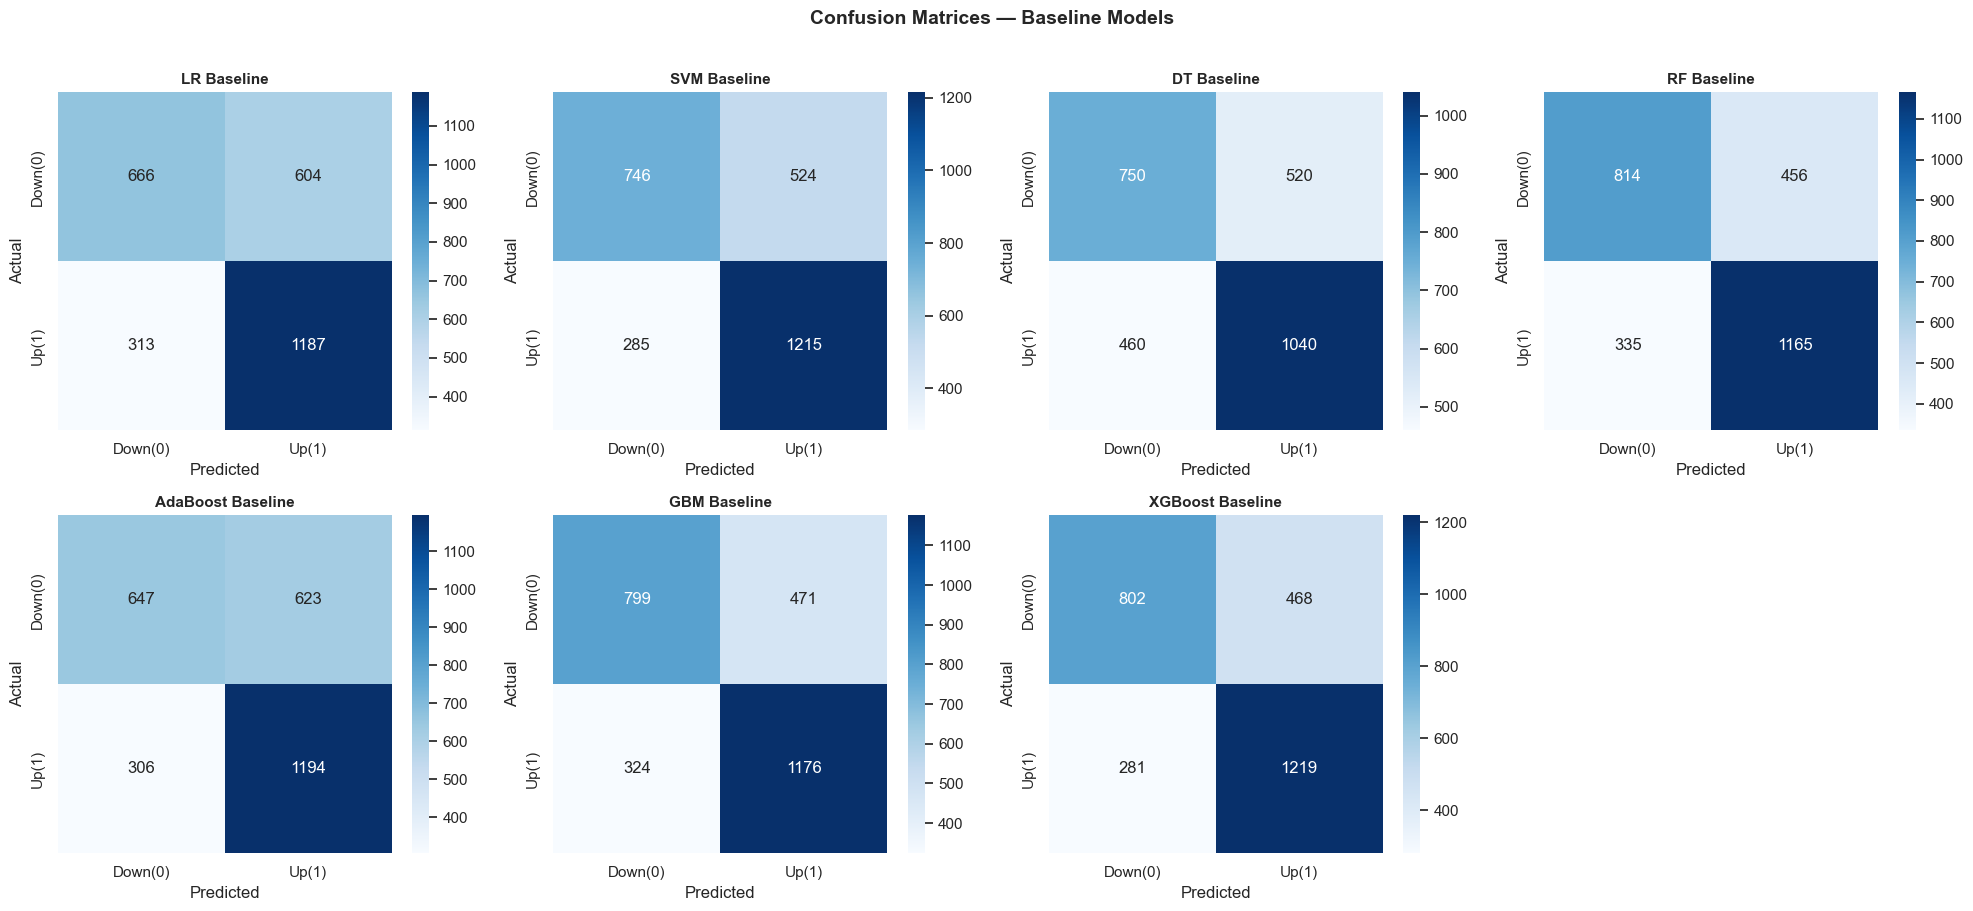

In [43]:
# Step 5.3 — Confusion Matrices: Baseline Models (display only — no save)
baseline_keys = ["lr_baseline", "svc_baseline", "dt_baseline", "rf_baseline",
                 "ada_baseline", "gbm_baseline", "xgb_baseline"]
try:
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    axes = axes.flatten()
    for idx, key in enumerate(baseline_keys):
        if key not in all_preds:
            axes[idx].set_visible(False)
            continue
        cm = confusion_matrix(y_test, all_preds[key])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx],
                    xticklabels=["Down(0)", "Up(1)"],
                    yticklabels=["Down(0)", "Up(1)"])
        axes[idx].set_title(model_display_names[key], fontsize=11, fontweight="bold")
        axes[idx].set_xlabel("Predicted")
        axes[idx].set_ylabel("Actual")
    axes[-1].set_visible(False)
    fig.suptitle("Confusion Matrices — Baseline Models", fontsize=14,
                 fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"[ERROR] Baseline confusion matrix plot: {e}")

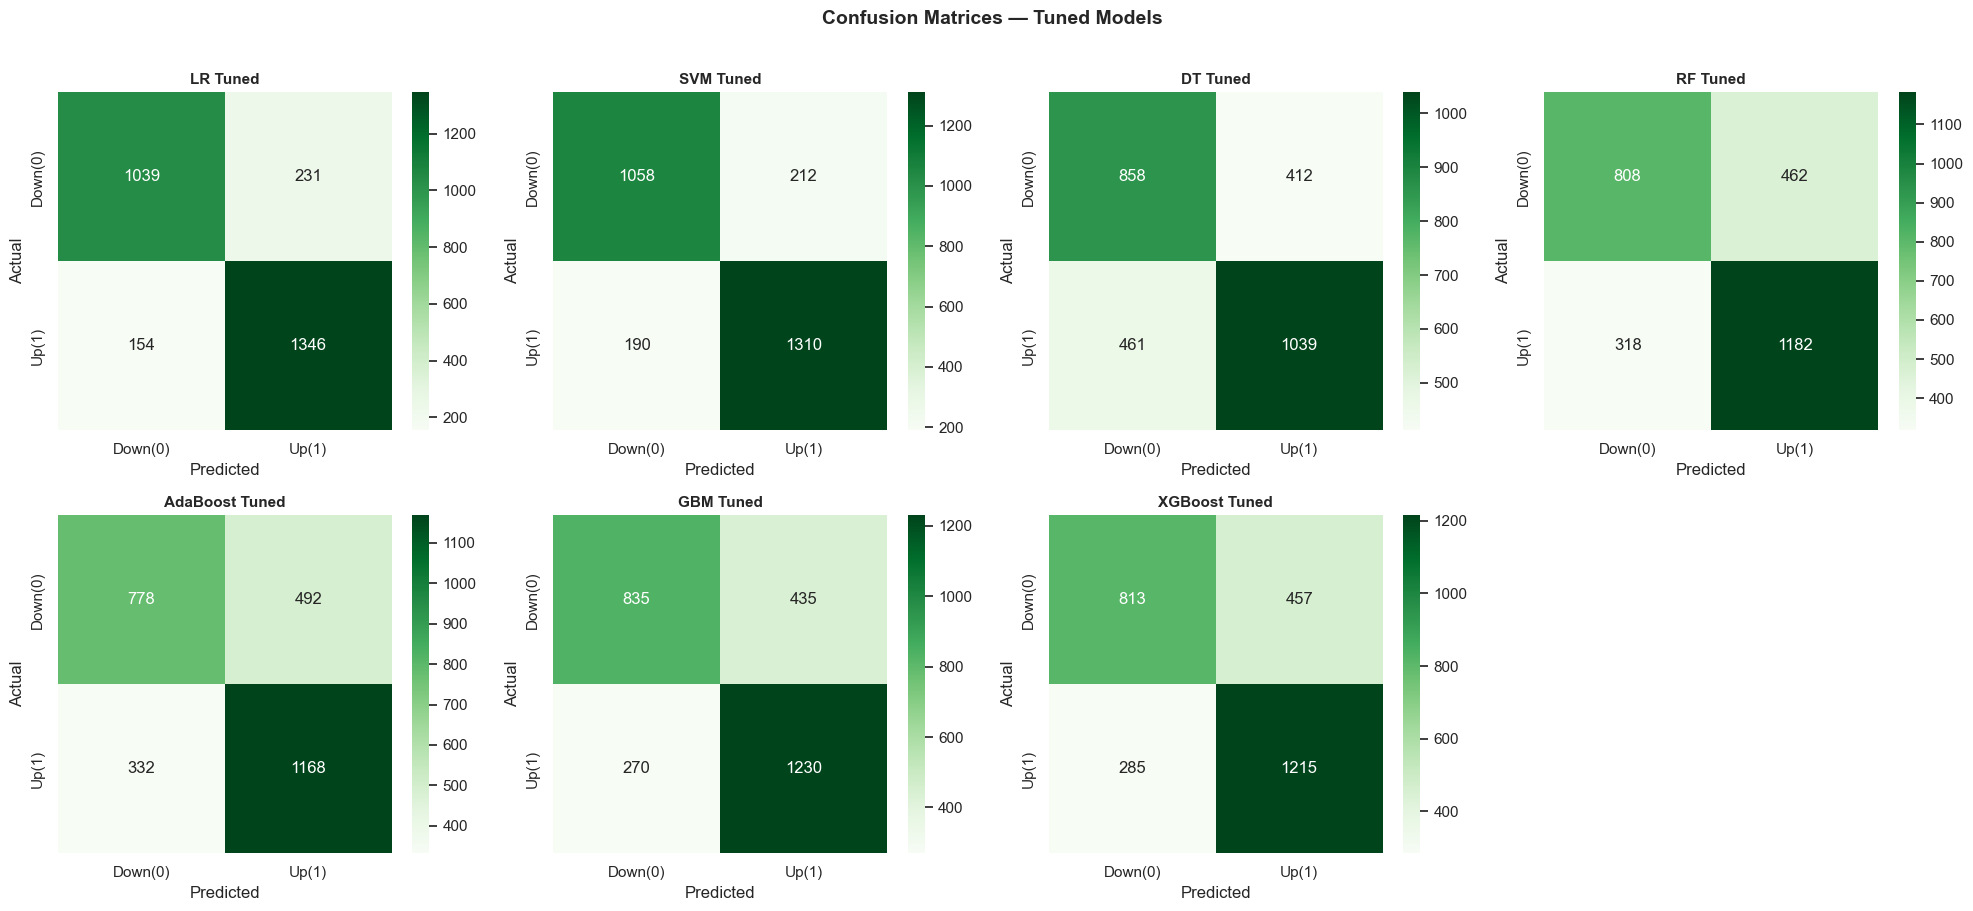

In [44]:
# Step 5.4 — Confusion Matrices: Tuned Models (display only — no save)
tuned_keys = ["lr_best", "svc_best", "dt_best", "rf_best",
              "ada_best", "gbm_best", "xgb_best"]
try:
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    axes = axes.flatten()
    for idx, key in enumerate(tuned_keys):
        if key not in all_preds:
            axes[idx].set_visible(False)
            continue
        cm = confusion_matrix(y_test, all_preds[key])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=axes[idx],
                    xticklabels=["Down(0)", "Up(1)"],
                    yticklabels=["Down(0)", "Up(1)"])
        axes[idx].set_title(model_display_names[key], fontsize=11, fontweight="bold")
        axes[idx].set_xlabel("Predicted")
        axes[idx].set_ylabel("Actual")
    axes[-1].set_visible(False)
    fig.suptitle("Confusion Matrices — Tuned Models", fontsize=14,
                 fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"[ERROR] Tuned confusion matrix plot: {e}")

In [45]:
# Step 5.5 — Tuned Models Comparison Summary Table
# Sorted by ROC-AUC descending; saved to output as eval_model_comparison.csv
tuned_label_set = {model_display_names[k] for k in tuned_keys}
tuned_df = (
    metrics_df[metrics_df["Model"].isin(tuned_label_set)]
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)
tuned_df.index     = tuned_df.index + 1
tuned_df.index.name = "Rank"

styled = (
    tuned_df.style
    .highlight_max(subset=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
                   color="#d4f1c5")
    .format({"Accuracy": "{:.4f}", "Precision": "{:.4f}",
             "Recall": "{:.4f}", "F1": "{:.4f}", "ROC-AUC": "{:.4f}"})
    .set_caption("Tuned Models — Test Set Performance (sorted by ROC-AUC descending)")
)
display(styled)

# Save comparison table (one of three permitted output files)
csv_path = os.path.join(output_dir, "eval_model_comparison.csv")
tuned_df.to_csv(csv_path)
print(f"Saved: {csv_path}")

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
Rank,,,,,,
1,LR Tuned,0.8610,0.8535,0.8973,0.8749,0.9354
2,SVM Tuned,0.8549,0.8607,0.8733,0.8670,0.9316
3,GBM Tuned,0.7455,0.7387,0.8200,0.7773,0.8215
4,XGBoost Tuned,0.7321,0.7267,0.8100,0.7661,0.8093
5,RF Tuned,0.7184,0.7190,0.7880,0.7519,0.7950
6,AdaBoost Tuned,0.7025,0.7036,0.7787,0.7392,0.7736
7,DT Tuned,0.6848,0.7161,0.6927,0.7042,0.7498


Saved: ..\..\output\eval_model_comparison.csv


In [46]:
# Step 5.6 — Baseline vs Tuned: Metric Delta Table (display only — no save)
# Note: Use Styler.map() — applymap() is deprecated in pandas >= 2.1
algo_map = [
    ("LR Baseline",       "LR Tuned"),
    ("SVM Baseline",      "SVM Tuned"),
    ("DT Baseline",       "DT Tuned"),
    ("RF Baseline",       "RF Tuned"),
    ("AdaBoost Baseline", "AdaBoost Tuned"),
    ("GBM Baseline",      "GBM Tuned"),
    ("XGBoost Baseline",  "XGBoost Tuned"),
]

rows = []
for base_label, tuned_label in algo_map:
    base_row  = metrics_df[metrics_df["Model"] == base_label]
    tuned_row = metrics_df[metrics_df["Model"] == tuned_label]
    if base_row.empty or tuned_row.empty:
        continue
    b    = base_row.iloc[0]
    t    = tuned_row.iloc[0]
    algo = base_label.replace(" Baseline", "")
    for metric in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
        rows.append({"Algorithm": algo, "Metric": metric,
                     "Baseline": b[metric], "Tuned": t[metric],
                     "Delta": round(t[metric] - b[metric], 4)})

bvt_df = pd.DataFrame(rows)

def color_delta(val):
    color = "green" if val > 0 else ("red" if val < 0 else "black")
    return f"color: {color}"

display(
    bvt_df.style
    .map(color_delta, subset=["Delta"])
    .format({"Baseline": "{:.4f}", "Tuned": "{:.4f}", "Delta": "{:+.4f}"})
    .set_caption("Baseline vs Tuned — Metric Delta per Algorithm")
)

,Algorithm,Metric,Baseline,Tuned,Delta
0,LR,Accuracy,0.6690,0.8610,+0.1920
1,LR,Precision,0.6628,0.8535,+0.1907
2,LR,Recall,0.7913,0.8973,+0.1060
3,LR,F1,0.7214,0.8749,+0.1535
4,LR,ROC-AUC,0.7424,0.9354,+0.1930
5,SVM,Accuracy,0.7079,0.8549,+0.1470
6,SVM,Precision,0.6987,0.8607,+0.1620
7,SVM,Recall,0.8100,0.8733,+0.0633
8,SVM,F1,0.7502,0.8670,+0.1168
9,SVM,ROC-AUC,0.7766,0.9316,+0.1550


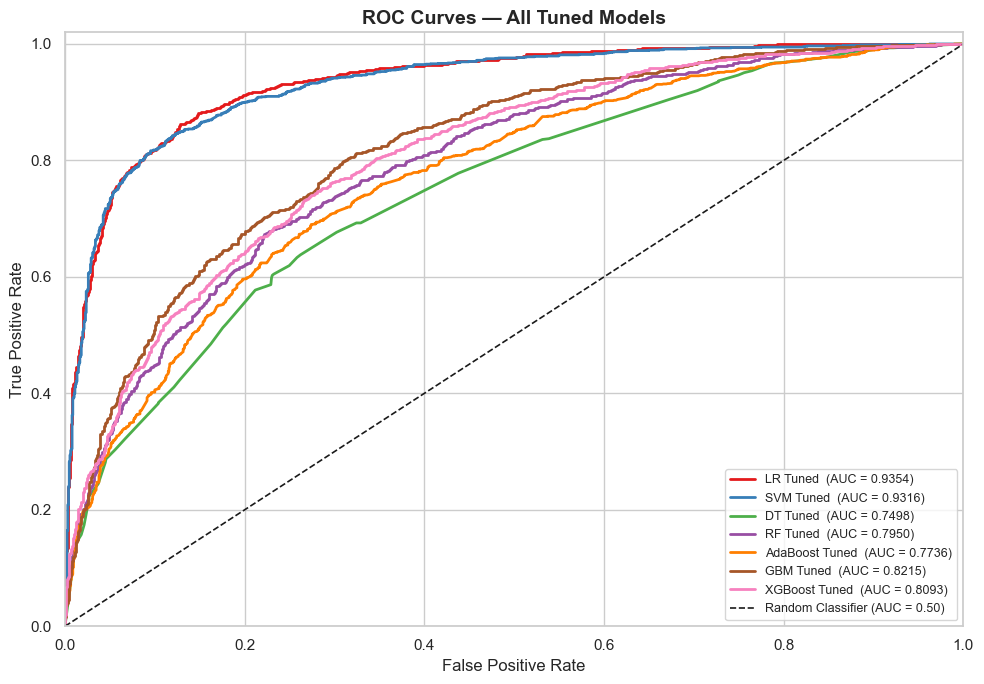

In [47]:
# Step 5.7 — ROC Curves: All Tuned Models (display only — no save)
try:
    fig, ax = plt.subplots(figsize=(10, 7))
    colors  = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3",
               "#ff7f00", "#a65628", "#f781bf"]
    for idx, key in enumerate(tuned_keys):
        if key not in all_probs or all_probs[key] is None:
            continue
        fpr, tpr, _ = roc_curve(y_test, all_probs[key])
        roc_auc_val = auc(fpr, tpr)
        label = f"{model_display_names[key]}  (AUC = {roc_auc_val:.4f})"
        ax.plot(fpr, tpr, color=colors[idx % len(colors)], lw=2, label=label)
    ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random Classifier (AUC = 0.50)")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title("ROC Curves — All Tuned Models", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"[ERROR] ROC curve plot: {e}")

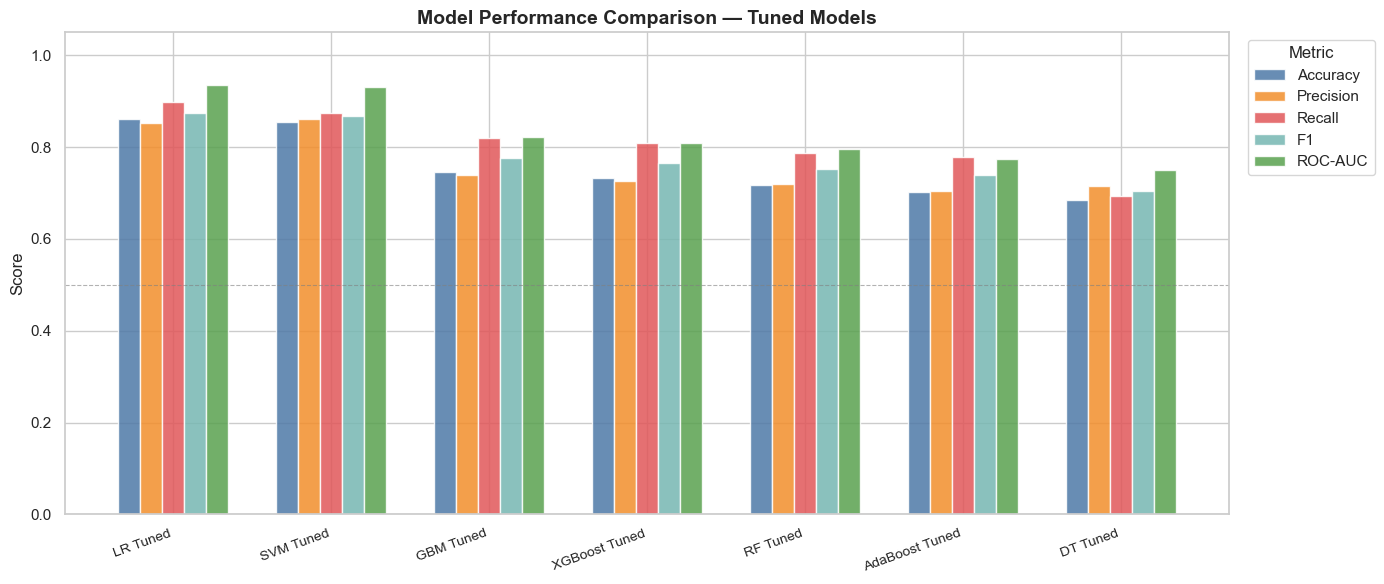

In [48]:
# Step 5.8 — Metric Comparison Bar Chart: Tuned Models (display only — no save)
try:
    metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
    plot_df     = tuned_df.set_index("Model")[metric_cols]
    fig, ax     = plt.subplots(figsize=(14, 6))
    x           = np.arange(len(plot_df))
    width       = 0.14
    bar_colors  = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f"]
    for i, (metric, color) in enumerate(zip(metric_cols, bar_colors)):
        ax.bar(x + i * width, plot_df[metric], width, label=metric,
               color=color, alpha=0.85)
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels(plot_df.index, rotation=20, ha="right", fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Model Performance Comparison — Tuned Models",
                 fontsize=14, fontweight="bold")
    ax.legend(title="Metric", bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.axhline(y=0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"[ERROR] Metric bar chart: {e}")

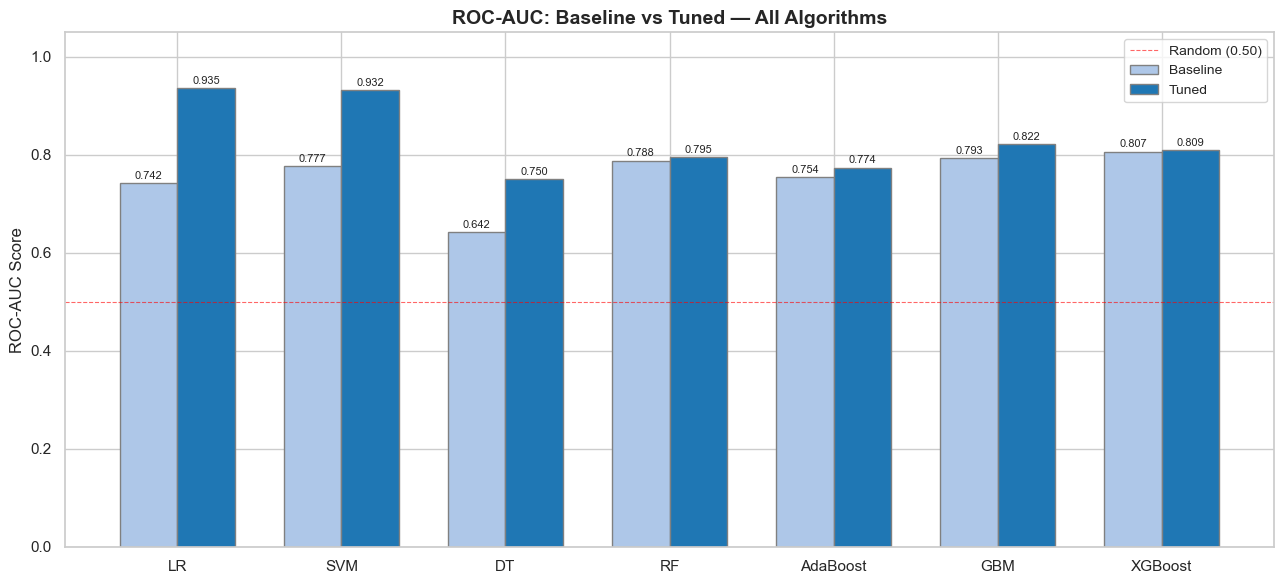

In [49]:
# Step 5.9 — Baseline vs Tuned ROC-AUC Bar Chart (display only — no save)
try:
    algos         = ["LR", "SVM", "DT", "RF", "AdaBoost", "GBM", "XGBoost"]
    base_keys_auc = ["lr_baseline", "svc_baseline", "dt_baseline", "rf_baseline",
                     "ada_baseline", "gbm_baseline", "xgb_baseline"]
    tuned_keys_auc= ["lr_best", "svc_best", "dt_best", "rf_best",
                     "ada_best", "gbm_best", "xgb_best"]

    def get_auc(key):
        row = metrics_df[metrics_df["Model"] == model_display_names[key]]
        return float(row["ROC-AUC"].values[0]) if not row.empty else 0.0

    base_auc  = [get_auc(k) for k in base_keys_auc]
    tuned_auc = [get_auc(k) for k in tuned_keys_auc]

    x   = np.arange(len(algos))
    w   = 0.35
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.bar(x - w/2, base_auc,  w, label="Baseline", color="#aec7e8", edgecolor="grey")
    ax.bar(x + w/2, tuned_auc, w, label="Tuned",    color="#1f77b4", edgecolor="grey")
    for i, (b, t) in enumerate(zip(base_auc, tuned_auc)):
        ax.text(x[i] - w/2, b + 0.005, f"{b:.3f}", ha="center", va="bottom", fontsize=8)
        ax.text(x[i] + w/2, t + 0.005, f"{t:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(algos, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.axhline(y=0.5, color="red", linestyle="--", linewidth=0.8, alpha=0.6,
               label="Random (0.50)")
    ax.set_ylabel("ROC-AUC Score", fontsize=12)
    ax.set_title("ROC-AUC: Baseline vs Tuned — All Algorithms",
                 fontsize=14, fontweight="bold")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"[ERROR] AUC comparison chart: {e}")

In [50]:
# Step 5.10 — Classification Reports: All Tuned Models
print("=" * 60)
print("=== CLASSIFICATION REPORTS — ALL TUNED MODELS ===")
print("=" * 60)
for key in tuned_keys:
    if key not in all_preds:
        continue
    label = model_display_names[key]
    print(f"\n--- {label} ---")
    print(classification_report(y_test, all_preds[key],
                                target_names=["Down (0)", "Up (1)"]))

=== CLASSIFICATION REPORTS — ALL TUNED MODELS ===

--- LR Tuned ---
              precision    recall  f1-score   support

    Down (0)       0.87      0.82      0.84      1270
      Up (1)       0.85      0.90      0.87      1500

    accuracy                           0.86      2770
   macro avg       0.86      0.86      0.86      2770
weighted avg       0.86      0.86      0.86      2770


--- SVM Tuned ---
              precision    recall  f1-score   support

    Down (0)       0.85      0.83      0.84      1270
      Up (1)       0.86      0.87      0.87      1500

    accuracy                           0.85      2770
   macro avg       0.85      0.85      0.85      2770
weighted avg       0.85      0.85      0.85      2770


--- DT Tuned ---
              precision    recall  f1-score   support

    Down (0)       0.65      0.68      0.66      1270
      Up (1)       0.72      0.69      0.70      1500

    accuracy                           0.68      2770
   macro avg       0.68

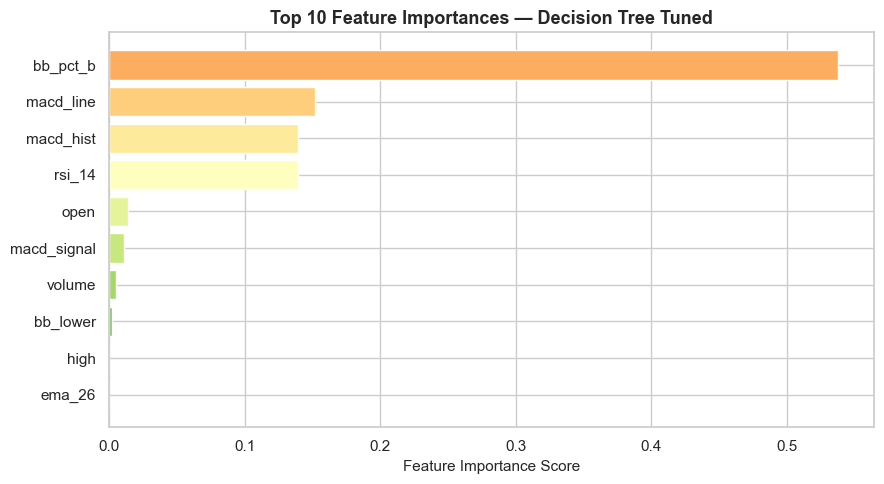

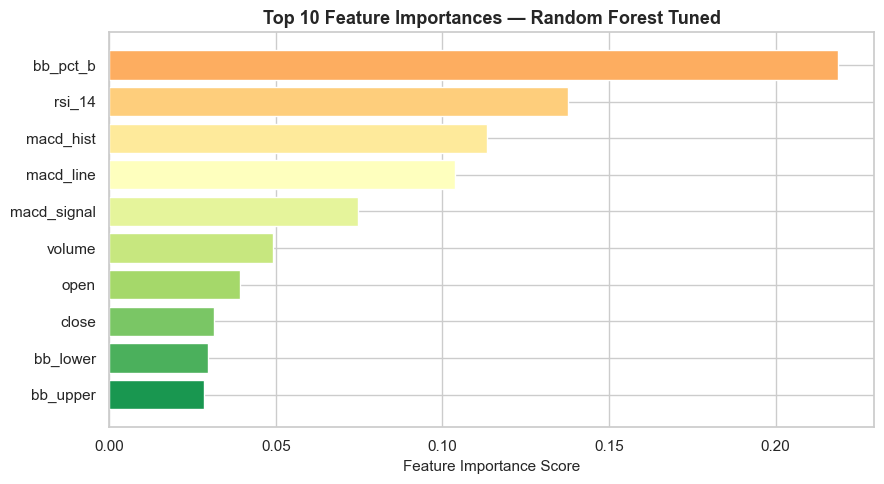

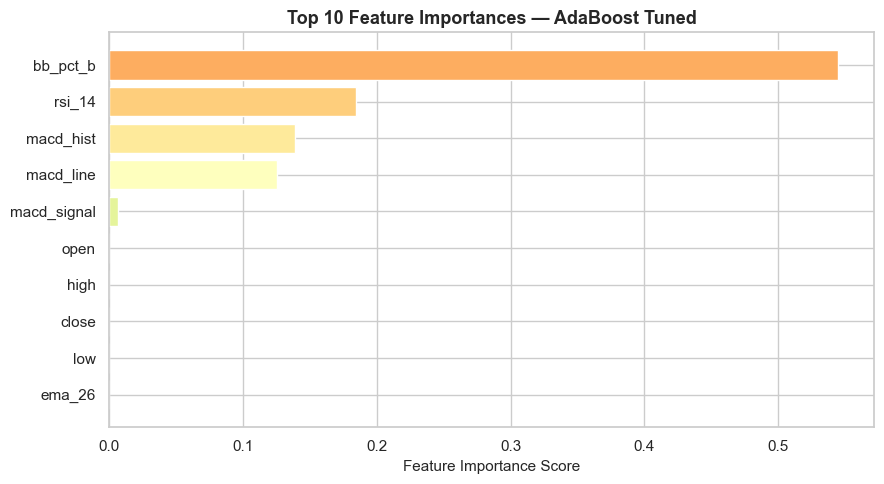

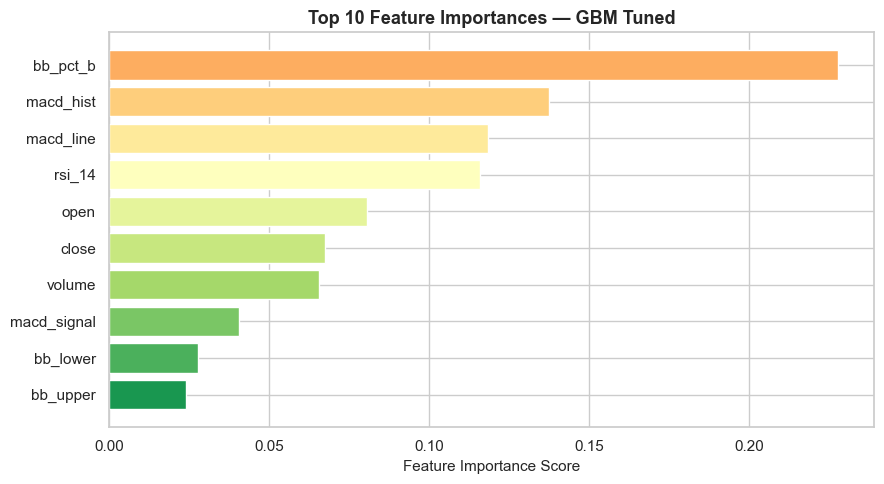

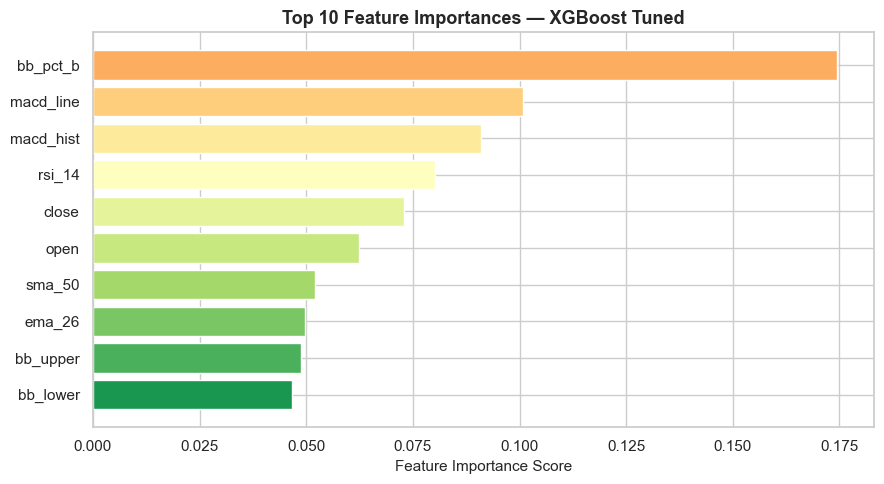

In [51]:
# Step 5.11 — Feature Importance: Tree/Boosting Tuned Models
#             (display only — no save; LR and SVM do not expose feature_importances_)
tree_boosting_models = {
    "dt_best"  : "Decision Tree Tuned",
    "rf_best"  : "Random Forest Tuned",
    "ada_best" : "AdaBoost Tuned",
    "gbm_best" : "GBM Tuned",
    "xgb_best" : "XGBoost Tuned",
}
feature_names = X_train.columns.tolist()

for model_key, label in tree_boosting_models.items():
    if model_key not in models:
        print(f"  [SKIP] {model_key} not available.")
        continue
    try:
        importances = models[model_key].feature_importances_
        fi_series   = (pd.Series(importances, index=feature_names)
                         .sort_values(ascending=False)
                         .head(10))
        fig, ax    = plt.subplots(figsize=(9, 5))
        bar_colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(fi_series)))
        ax.barh(fi_series.index[::-1], fi_series.values[::-1],
                color=bar_colors[::-1])
        ax.set_xlabel("Feature Importance Score", fontsize=11)
        ax.set_title(f"Top 10 Feature Importances — {label}",
                     fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"  [ERROR] {model_key}: {e}")

In [52]:
# Step 5.12 — Overfitting Check: Train vs Test Accuracy and ROC-AUC
OVERFIT_THRESHOLD = 0.05
overfit_rows = []

for model_key, label in {
    "lr_best": "LR Tuned", "svc_best": "SVM Tuned",
    "dt_best": "DT Tuned", "rf_best":  "RF Tuned",
    "ada_best": "AdaBoost Tuned", "gbm_best": "GBM Tuned",
    "xgb_best": "XGBoost Tuned"
}.items():
    if model_key not in models:
        print(f"  [SKIP] {model_key}")
        continue
    try:
        model        = models[model_key]
        y_train_pred = model.predict(X_train)
        train_acc    = accuracy_score(y_train, y_train_pred)
        train_auc    = (roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
                        if hasattr(model, "predict_proba") else None)
        y_test_pred  = model.predict(X_test)
        test_acc     = accuracy_score(y_test, y_test_pred)
        test_auc     = (roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
                        if hasattr(model, "predict_proba") else None)
        acc_gap      = round(train_acc - test_acc, 4)
        auc_gap      = round(train_auc - test_auc, 4) if (train_auc and test_auc) else None
        overfit_flag = ("POTENTIALLY OVERFIT"
                        if auc_gap is not None and auc_gap > OVERFIT_THRESHOLD else "OK")
        overfit_rows.append({
            "Model": label,
            "Train Acc": round(train_acc, 4), "Test Acc": round(test_acc, 4),
            "Acc Gap": acc_gap,
            "Train AUC": round(train_auc, 4) if train_auc else None,
            "Test AUC":  round(test_auc,  4) if test_auc  else None,
            "AUC Gap": auc_gap, "Status": overfit_flag,
        })
        auc_str = f"{auc_gap:.4f}" if auc_gap is not None else "N/A"
        if overfit_flag != "OK":
            print(f"  [WARNING] {label:<22} AUC Gap = {auc_str}  → {overfit_flag}")
        else:
            print(f"  {label:<22} AUC Gap = {auc_str}  ({overfit_flag})")
    except Exception as e:
        print(f"  [ERROR] {model_key}: {e}")

overfit_df = pd.DataFrame(overfit_rows)
display(
    overfit_df.style
    .format({"Train Acc": "{:.4f}", "Test Acc": "{:.4f}", "Acc Gap": "{:+.4f}",
             "Train AUC": "{:.4f}", "Test AUC": "{:.4f}", "AUC Gap": "{:+.4f}"},
            na_rep="N/A")
    .set_caption(f"Overfitting Check — Tuned Models  (flag if AUC gap > {OVERFIT_THRESHOLD})")
)

  LR Tuned               AUC Gap = -0.0009  (OK)
  SVM Tuned              AUC Gap = 0.0050  (OK)
  DT Tuned               AUC Gap = 0.0464  (OK)
  [WARNING] RF Tuned               AUC Gap = 0.1928  → POTENTIALLY OVERFIT
  AdaBoost Tuned         AUC Gap = 0.0286  (OK)
  [WARNING] GBM Tuned              AUC Gap = 0.1785  → POTENTIALLY OVERFIT
  [WARNING] XGBoost Tuned          AUC Gap = 0.1309  → POTENTIALLY OVERFIT


,Model,Train Acc,Test Acc,Acc Gap,Train AUC,Test AUC,AUC Gap,Status
0,LR Tuned,0.8682,0.8610,+0.0072,0.9345,0.9354,-0.0009,OK
1,SVM Tuned,0.8650,0.8549,+0.0101,0.9366,0.9316,+0.0050,OK
2,DT Tuned,0.7121,0.6848,+0.0273,0.7962,0.7498,+0.0464,OK
3,RF Tuned,0.9391,0.7184,+0.2207,0.9878,0.7950,+0.1928,POTENTIALLY OVERFIT
4,AdaBoost Tuned,0.7255,0.7025,+0.0230,0.8022,0.7736,+0.0286,OK
5,GBM Tuned,1.0000,0.7455,+0.2545,1.0000,0.8215,+0.1785,POTENTIALLY OVERFIT
6,XGBoost Tuned,0.8643,0.7321,+0.1322,0.9402,0.8093,+0.1309,POTENTIALLY OVERFIT


In [53]:
# Step 5.13 — Final Summary
print("=" * 60)
print("=== FINAL SUMMARY ===")
print("=" * 60)

best_row = tuned_df.iloc[0]
print(f"\n  Best Model  : {best_row['Model']}")
print(f"  ROC-AUC    : {best_row['ROC-AUC']:.4f}")
print(f"  Accuracy   : {best_row['Accuracy']:.4f}")
print(f"  Precision  : {best_row['Precision']:.4f}")
print(f"  Recall     : {best_row['Recall']:.4f}")
print(f"  F1         : {best_row['F1']:.4f}")

=== FINAL SUMMARY ===

  Best Model  : LR Tuned
  ROC-AUC    : 0.9354
  Accuracy   : 0.8610
  Precision  : 0.8535
  Recall     : 0.8973
  F1         : 0.8749


## Section 6 — Save Artifacts

In [54]:
print("=" * 60)
print("=== SECTION 6: SAVE ARTIFACTS ===")
print("=" * 60)

# Step 6.1 — Save Best Model
# Best model identified from tuned_df (already sorted by Test ROC-AUC descending)
best_display_label = tuned_df.iloc[0]["Model"]
best_roc_auc       = tuned_df.iloc[0]["ROC-AUC"]
display_to_key     = {v: k for k, v in model_display_names.items()}
best_model_key     = display_to_key[best_display_label]
best_model_obj     = models[best_model_key]

print(f"  Best model   : {best_display_label}  (key: {best_model_key})")
print(f"  Test ROC-AUC : {best_roc_auc:.4f}")

best_model_path = os.path.join(output_dir, "best_model.pkl")
joblib.dump(best_model_obj, best_model_path)
print(f"\n  Saved best model → {os.path.abspath(best_model_path)}")

# Step 6.2 — Save Scaler
# The scaler was fitted on X_train in Step 3.5 and is already in-memory.
# Do NOT re-fit here — just persist the existing fitted scaler object.
scaler_path = os.path.join(output_dir, "scaler.pkl")
joblib.dump(scaler, scaler_path)
print(f"  Saved scaler     → {os.path.abspath(scaler_path)}")

print("\n  Artifacts saved to output/:")
print("    best_model.pkl")
print("    scaler.pkl")
print("    eval_model_comparison.csv")
print("\n  Both artifacts are ready for inference / deployment.")

=== SECTION 6: SAVE ARTIFACTS ===
  Best model   : LR Tuned  (key: lr_best)
  Test ROC-AUC : 0.9354

  Saved best model → e:\Python_projects\Coursera\Classification-badge\s_n_p_classifier\model_files\output\best_model.pkl
  Saved scaler     → e:\Python_projects\Coursera\Classification-badge\s_n_p_classifier\model_files\output\scaler.pkl

  Artifacts saved to output/:
    best_model.pkl
    scaler.pkl
    eval_model_comparison.csv

  Both artifacts are ready for inference / deployment.
